<div style="text-align: center;">

# Sustainability Aware Asset Management  
# Portfolio Allocation with a Carbon Objective  

<br>

**Course:** Sustainability Aware Asset Management<br>
**Instructor:** Professor Eric Jondeau<br> 
**Academic Year:** 2025–2026<br>  

<br>

**Group Members**  
Matteo Piras<br>
Tomas Papuga<br> 
Marco d'Amico<br>
Roberto Berardi<br> 

<br>

**Submission Date:** May 2026  

</div>

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from IPython.display import display


# Part I - Standard Portfolio Allocation
## 1) Data Cleaning

### 1.1) Missing Prices and Datastream Error Rows

The raw datasets are direct exports from Datastream and may contain structural inconsistencies that must be addressed before any financial analysis.

Some ISIN codes are flagged with `$$ER`, indicating that Datastream could not correctly match the requested security (for example, due to share class mismatches or unavailable data). These rows do not contain valid financial information and are therefore removed from all datasets.

We then standardize the structure of each file by:
- Converting ISIN codes to a consistent string format,
- Removing non-numeric columns such as firm names,
- Transposing the data so that dates form the index and firms form the columns,
- Converting all values to numeric format.

At this stage, we only correct structural and data-quality issues. No economic filtering (region, carbon availability, liquidity, etc.) is applied yet. 

In [14]:
print("Starting finalized data preparation process...")

# --------------------------------------------------------
# 1. Setup and Static Data Filtering
# --------------------------------------------------------
# Load the static dataset to identify the initial investment universe
static_df = pd.read_excel('Data_2026/Static_2025.xlsx')
static_df['ISIN'] = static_df['ISIN'].astype(str).str.strip()

# Isolate firms belonging to the Emerging Markets (EM) region
em_firms = static_df[static_df['Region'] == 'EM'].copy()
valid_em_isins = em_firms['ISIN'].unique().tolist()

def load_and_transpose(filepath, is_monthly=False):
    """
    Standardizes Datastream Excel exports into time-series DataFrames.
    Removes error flags ($$ER) and transposes firms to columns.
    """
    df = pd.read_excel(filepath)
    # Rule: Explicitly delete ISINs with Datastream errors ($$ER)
    df = df[~df['ISIN'].astype(str).str.contains(r'\$\$ER', na=False)]
    df['ISIN'] = df['ISIN'].astype(str).str.strip()
    df.set_index('ISIN', inplace=True)
    
    if 'NAME' in df.columns:
        df.drop(columns=['NAME'], inplace=True)
    
    df_t = df.T
    df_t = df_t.apply(pd.to_numeric, errors='coerce')
    
    # Handle indexing based on data frequency (Monthly for RI, Yearly for Carbon)
    if is_monthly:
        df_t.index = pd.to_datetime(df_t.index)
    else:
        df_t.index = df_t.index.astype(int)
    return df_t

print("Static data loaded and EM firms identified.")

Starting finalized data preparation process...
Static data loaded and EM firms identified.


### 1.2) Missing Values: Beginning, Middle, and End of Sample

The datasets contain different types of missing observations that must be handled carefully to ensure consistent return estimation and avoid distortions in portfolio construction.

First, missing values at the beginning of the sample typically correspond to firms that were not yet listed or had not started reporting data. In this case, no correction is applied.

Second, missing values between two available observations usually reflect temporary reporting gaps or data issues. To preserve continuity in the return series, we apply a forward-fill procedure to bridge these internal gaps.

Third, missing values at the end of the sample generally correspond to firm delisting or default events. In such cases, the price is assumed to drop to zero, implying a realized return of −100% in the month following the last valid observation. All subsequent periods are set to missing values to avoid artificially lowering volatility.

This treatment ensures a realistic handling of firm exits while maintaining the integrity of the historical return series.

In [15]:
# --------------------------------------------------------
# 2. Return Index (RI) Processing with Delisting Logic
# --------------------------------------------------------
ri_monthly = load_and_transpose('Data_2026/DS_RI_T_USD_M_2025.xlsx', is_monthly=True)
ri_em = ri_monthly[[isin for isin in valid_em_isins if isin in ri_monthly.columns]].copy()

# Rule: Treat prices < 0.5 as missing values to avoid extreme returns from penny stocks
ri_em[ri_em < 0.5] = np.nan

# CRITICAL: Identify the real last valid date BEFORE filling gaps.
# This ensures that delisting (final disappearance) is not masked by forward-filling.
real_last_valid_dates = ri_em.apply(lambda col: col.last_valid_index())

# Rule: Fill gaps between available values (Forward Fill) to bridge misreporting
ri_em_filled = ri_em.ffill()
returns_em = ri_em_filled.pct_change(fill_method=None)

# Applying Precise Delisting Logic: -100% loss followed by NaNs
for isin in returns_em.columns:
    last_date = real_last_valid_dates[isin]
    if pd.notna(last_date):
        last_pos = returns_em.index.get_loc(last_date)
        
        # If the firm disappears before the end of the sample, acknowledge the loss
        if last_pos < len(returns_em) - 1:
            # Force -100% return in the month following the last valid price
            returns_em.iloc[last_pos + 1, returns_em.columns.get_loc(isin)] = -1.0
            
            # Ensure post-delisting periods are NaN (not zero) to avoid stale price/low volatility bias
            if last_pos + 1 < len(returns_em) - 1:
                returns_em.iloc[last_pos + 2:, returns_em.columns.get_loc(isin)] = np.nan
    else:
        # Mark firms with no valid data for complete removal
        returns_em[isin] = np.nan

### 1.3) Carbon Data Preparation and Validation

Scope 1 and Scope 2 carbon emissions data are first loaded from the Datastream files and transformed into annual time-series format. The sample is then restricted to firms belonging to the Emerging Markets universe.

To account for reporting gaps across years, carbon emissions data are forward-filled. This means that when a firm does not report emissions in a given year, the most recent available observation is carried forward.

After this step, firms with no available data at all are removed from the corresponding datasets. The same cleaning rule is also applied to the returns matrix, so that firms without usable information are excluded from the analysis.

Finally, a validation summary is printed to check the dimensions of the returns, Scope 1, and Scope 2 datasets before proceeding with the next steps.

In [16]:

scope1_em = load_and_transpose('Data_2026/DS_CO2_SCOPE_1_Y_2025.xlsx', is_monthly=False)
scope2_em = load_and_transpose('Data_2026/DS_CO2_SCOPE_2_Y_2025.xlsx', is_monthly=False)

# Filter for EM and apply Forward Fill for reporting gaps between years
scope1_em = scope1_em[[isin for isin in valid_em_isins if isin in scope1_em.columns]].copy().ffill()
scope2_em = scope2_em[[isin for isin in valid_em_isins if isin in scope2_em.columns]].copy().ffill()

# Rule: Physically delete firms with no associated data from all tables
returns_em.dropna(how='all', axis=1, inplace=True)
scope1_em.dropna(how='all', axis=1, inplace=True)
scope2_em.dropna(how='all', axis=1, inplace=True)

print("Data Validation Overview:")
print(f"- Returns Matrix: {returns_em.shape[0]} months, {returns_em.shape[1]} firms")
print(f"- Scope 1/2 Matrices: {scope1_em.shape[0]} years")
display(returns_em.head())

Data Validation Overview:
- Returns Matrix: 314 months, 668 firms
- Scope 1/2 Matrices: 27 years


ISIN,ARALUA010258,ARP125991090,ARSIDE010029,BMG211591018,BRABEVACNOR1,BRBBASACNOR3,BRBBDCACNPR8,BRBRFSACNOR8,BRBRKMACNPA4,BRCESPACNPB4,...,ZAE000117321,ZAE000127148,ZAE000134961,ZAE000170049,ZAE000179420,ZAE000191342,ZAE000255915,ZAE000298253,ZAE000302618,ZAE000322095
1999-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-31,0.176511,-0.051861,-0.004877,NaN,-0.044175,-0.067245,0.023986,-0.249634,0.011906,NaN,...,-0.115161,-0.049527,0.096965,0.067794,0.205596,0.099568,-0.080722,0.125341,0.021174,-0.114179
2000-02-29,0.050002,0.178923,0.039543,NaN,-0.045539,-0.036328,-0.107794,0.005452,0.043492,NaN,...,-0.037800,-0.100608,-0.326248,0.028928,-0.053481,-0.084315,-0.062844,-0.181598,0.018379,-0.023150
2000-03-31,-0.023552,-0.105072,-0.002113,NaN,0.313941,-0.130625,0.152061,0.014002,0.002361,NaN,...,-0.067887,-0.034040,-0.044066,-0.176088,-0.126866,0.073915,-0.054382,-0.038462,-0.142989,-0.104274
2000-04-28,-0.016173,-0.161842,-0.071188,NaN,-0.001350,-0.077311,-0.108617,-0.032966,-0.020143,NaN,...,-0.034586,-0.042240,-0.172342,-0.129131,-0.035409,-0.208833,-0.030503,-0.224615,-0.095572,0.003496


### 1.4) Dynamic Investment Set Construction (10-Year Rolling Window)

After cleaning the data, we construct the investment universe dynamically for each portfolio formation year.

For each year 
𝑌
Y, we use a 10-year rolling estimation window (from January 
𝑌
−
9
Y−9 to December 
𝑌
Y) to determine firm eligibility. The portfolio formed at the end of year 
𝑌
Y is implemented during year 
𝑌
+
1
Y+1.

A firm is included in the investment set only if it satisfies all of the following conditions:

Price availability at formation date:
The firm must have a valid price at the end of year 
𝑌
Y. Firms with missing or invalid prices at the portfolio formation date are excluded.

Liquidity condition (stale price filter):
Over the 10-year estimation window, the proportion of zero monthly returns must not exceed 50%. This ensures that illiquid firms do not artificially reduce estimated portfolio volatility.

Carbon data availability:
Both Scope 1 and Scope 2 emissions data must be available at the end of year 
𝑌
Y. This guarantees consistency between the financial allocation and the sustainability analysis.

The resulting set of eligible firms is stored for each holding year 
𝑌
+
1
Y+1, forming a sequence of dynamically updated investment universes.

In [17]:
print("Initiating dynamic filtering for 10-year rolling windows...")

# Step 5: Dynamic Universe Construction
# We identify eligible firms for each year based on historical liquidity and ESG disclosure.
valid_investment_sets = {}
estimation_years = range(2009, 2025)

for Y in estimation_years:
    # Define the 10-year rolling estimation window (Dec Y-9 to Dec Y)
    start_date, end_date = f"{Y-9}-01-01", f"{Y}-12-31"
    window_returns = returns_em.loc[start_date:end_date]
    window_prices = ri_em.loc[start_date:end_date]
    
    valid_isins_for_year = []
    
    for isin in returns_em.columns:
        # Rule: Price Availability at end of year Y
        # Exclude firms missing a valid price (>0.5 USD) at the portfolio formation date.
        if pd.isna(window_prices[isin].iloc[-1]):
            continue
            
        # Rule: Stale Price / Liquidity Filter
        # Calculate the ratio of months with zero returns to avoid illiquid assets.
        total_valid_months  = window_returns[isin].notna().sum()
        total_window_months = window_returns[isin].shape[0]   # always 120 months
        if total_valid_months < 60:
            continue
        
        # Exclude if the firm has no price movement for > 50% of the full 10-year window.
        # The PDF specifies the proportion is computed over the full estimation window (120 months),
        # not just the valid (non-NaN) months.
        if (window_returns[isin] == 0.0).sum() / total_window_months > 0.5:
            continue
            
        # Rule: Carbon Data Availability for Year Y
        # Both Scope 1 and Scope 2 data must be present for the firm to be eligible.
        if Y in scope1_em.index and Y in scope2_em.index:
            if isin in scope1_em.columns and isin in scope2_em.columns:
                if not pd.isna(scope1_em.loc[Y, isin]) and not pd.isna(scope2_em.loc[Y, isin]):
                    valid_isins_for_year.append(isin)
    
    # Store the investment set for the subsequent holding period (Y + 1)
    valid_investment_sets[Y + 1] = valid_isins_for_year
    print(f"Holding Year {Y+1}: {len(valid_isins_for_year)} firms identified.")

print("\nInvestment universes constructed successfully.")

Initiating dynamic filtering for 10-year rolling windows...
Holding Year 2010: 64 firms identified.
Holding Year 2011: 153 firms identified.
Holding Year 2012: 190 firms identified.
Holding Year 2013: 224 firms identified.
Holding Year 2014: 245 firms identified.
Holding Year 2015: 266 firms identified.
Holding Year 2016: 296 firms identified.
Holding Year 2017: 334 firms identified.
Holding Year 2018: 380 firms identified.
Holding Year 2019: 415 firms identified.
Holding Year 2020: 463 firms identified.
Holding Year 2021: 503 firms identified.
Holding Year 2022: 540 firms identified.
Holding Year 2023: 569 firms identified.
Holding Year 2024: 578 firms identified.
Holding Year 2025: 566 firms identified.

Investment universes constructed successfully.


# 2) Minimum-Variance Portfolio Allocation
### 2.1) Investment set: Estimation of Expected Returns and Covariance Matrices

In this section, we compute the return moments required for the portfolio optimization. For each portfolio formed at the end of year $Y$, we extract a 10-year rolling window of monthly returns (from January $Y-9$ to December $Y$) for the eligible investment set.

To strictly adhere to the provided mathematical framework, the calculations are implemented exactly as defined by the formulas:

- Missing Data Treatment: All missing returns within the estimation window are explicitly replaced by 0 before any computation. This ensures that the number of monthly observations ($\tau$) remains exactly 120 for all firms, avoiding the need to drop incomplete rows.
- Expected Returns: Calculated as the sum of returns over the window divided by the number of observations, perfectly mirroring the formula $\hat{\mu}_Y = \frac{1}{\tau} \sum R_{t-k}$.
- Covariance Matrix: Estimated using the exact population formula $\Sigma_Y = \frac{1}{\tau} \sum (R_{t-k} - \hat{\mu}_Y)'(R_{t-k} - \hat{\mu}_Y)$. To guarantee numerical precision, this is implemented using pure linear algebra operations, specifically the dot product of the centered return arrays divided by $\tau$.

The resulting expected returns and covariance matrices are stored in dictionaries and serve as the direct inputs for the subsequent minimum variance optimization.

In [18]:
print("Calculating Expected Returns and Covariance Matrices...")

# --------------------------------------------------------
# 6. Estimation of Expected Returns and Covariance Matrices
# --------------------------------------------------------
# Using the formulas exactly:
#
# mu_hat_Y = (1/tau) * sum R_t
#
# Sigma_Y = (1/tau) * sum (R_t - mu_hat_Y)'(R_t - mu_hat_Y)
#
# Missing values are replaced by 0 before computation.

mu_estimates = {}
sigma_estimates = {}

estimation_years = range(2009, 2025)

for Y in estimation_years:

    holding_year = Y + 1
    valid_isins = valid_investment_sets[holding_year]

    if len(valid_isins) == 0:
        print(f"Holding Year {holding_year}: no eligible firms.")
        continue

    # 10-year estimation window
    start_date, end_date = f"{Y-9}-01-01", f"{Y}-12-31"

    window_returns = returns_em.loc[start_date:end_date, valid_isins].copy()

    # Replace missing returns with 0
    window_returns = window_returns.fillna(0)

    # number of observations (should be 120 months)
    tau = window_returns.shape[0]

    # --------------------------------------------------------
    # Expected Returns (formula)
    # --------------------------------------------------------
    mu_hat_Y = window_returns.sum(axis=0) / tau

    # --------------------------------------------------------
    # Covariance Matrix (formula)
    # --------------------------------------------------------
    R = window_returns.to_numpy()            # tau x N
    mu = mu_hat_Y.to_numpy().reshape(1, -1)  # 1 x N

    # center returns
    R_centered = R - mu

    # covariance formula
    Sigma_array = (R_centered.T @ R_centered) / tau

    # convert back to dataframe
    Sigma_Y = pd.DataFrame(
        Sigma_array,
        index=window_returns.columns,
        columns=window_returns.columns
    )

    mu_estimates[holding_year] = mu_hat_Y
    sigma_estimates[holding_year] = Sigma_Y

    print(
        f"Holding Year {holding_year}: "
        f"{len(valid_isins)} firms, "
        f"tau={tau}, "
        f"mu size={mu_hat_Y.shape[0]}, "
        f"Sigma shape={Sigma_Y.shape}"
    )

print("\nExpected returns and covariance matrices computed successfully.")

# --------------------------------------------------------
# Example check
# --------------------------------------------------------
example_year = 2014
if example_year in mu_estimates and example_year in sigma_estimates:
    print(f"\nExample: Holding Year {example_year}")
    display(mu_estimates[example_year].head())
    display(sigma_estimates[example_year].iloc[:5, :5])

Calculating Expected Returns and Covariance Matrices...
Holding Year 2010: 64 firms, tau=120, mu size=64, Sigma shape=(64, 64)
Holding Year 2011: 153 firms, tau=120, mu size=153, Sigma shape=(153, 153)
Holding Year 2012: 190 firms, tau=120, mu size=190, Sigma shape=(190, 190)
Holding Year 2013: 224 firms, tau=120, mu size=224, Sigma shape=(224, 224)
Holding Year 2014: 245 firms, tau=120, mu size=245, Sigma shape=(245, 245)
Holding Year 2015: 266 firms, tau=120, mu size=266, Sigma shape=(266, 266)
Holding Year 2016: 296 firms, tau=120, mu size=296, Sigma shape=(296, 296)
Holding Year 2017: 334 firms, tau=120, mu size=334, Sigma shape=(334, 334)
Holding Year 2018: 380 firms, tau=120, mu size=380, Sigma shape=(380, 380)
Holding Year 2019: 415 firms, tau=120, mu size=415, Sigma shape=(415, 415)
Holding Year 2020: 463 firms, tau=120, mu size=463, Sigma shape=(463, 463)
Holding Year 2021: 503 firms, tau=120, mu size=503, Sigma shape=(503, 503)
Holding Year 2022: 540 firms, tau=120, mu size=5

ISIN
BRBBASACNOR3    0.024255
BRBBDCACNPR8    0.022722
BRBRFSACNOR8    0.032435
BRBRKMACNPA4    0.015174
BRCESPACNPB4    0.011178
dtype: float64

ISIN,BRBBASACNOR3,BRBBDCACNPR8,BRBRFSACNOR8,BRBRKMACNPA4,BRCESPACNPB4
ISIN,,,,,
BRBBASACNOR3,0.015590,0.010866,0.008129,0.007731,0.006893
BRBBDCACNPR8,0.010866,0.012099,0.008446,0.007131,0.005413
BRBRFSACNOR8,0.008129,0.008446,0.014663,0.006491,0.005183
BRBRKMACNPA4,0.007731,0.007131,0.006491,0.019695,0.004748
BRCESPACNPB4,0.006893,0.005413,0.005183,0.004748,0.014449


### 2.2) Minimum Variance Portfolio (Out-of-Sample)

We construct a **long-only minimum variance portfolio** using an out-of-sample framework.  
At the end of each year \(Y\), the portfolio weights \(\alpha_Y\) are computed using the covariance matrix \(\Sigma_Y\) estimated from the previous 10 years of monthly returns.

The optimal weights are obtained by solving the following optimization problem:

$$
\min_{\alpha_Y} \sigma_{p,Y}^2 = \alpha_Y' \Sigma_Y \alpha_Y
$$

subject to

$$
\alpha_Y' e = 1, \qquad \alpha_{i,Y} \ge 0
$$

where \(e = (1,\ldots,1)'\). This ensures that portfolio weights sum to one and remain non-negative.

The portfolio is **rebalanced annually** from December 2013 to December 2024. The weights determined at the end of year \(Y\) are applied during the following year \(Y+1\).

### Ex-Post Portfolio Returns

Monthly portfolio returns are computed during the holding year as

$$
R_{p,t+k} = \alpha'_{t+k-1} R_{t+k}, \qquad k = 1,\ldots,12
$$

Between rebalancing dates, portfolio weights evolve according to asset price movements:

$$
\alpha_{i,t+k} =
\alpha_{i,t+k-1}
\frac{1 + R_{i,t+k}}{1 + R_{p,t+k}}
$$

Applying this procedure produces a time series of **144 out-of-sample monthly portfolio returns**, covering the period from **January 2014 to December 2025**.

### Portfolio Performance

Finally, we compute the main characteristics of the minimum variance portfolio $P^{(mv)}_{oos}$:

- Annualized average return $\bar{\mu}_p$
- Annualized volatility $\sigma_p$
- Sharpe ratio $SR_p = \frac{\bar{R}_p - \bar{R}_f}{\sigma_p}$
- Minimum monthly return
- Maximum monthly return

The **long-only restriction** facilitates the interpretation of the portfolio’s carbon footprint in the following analysis.

In [19]:
print("Starting Minimum Variance Optimization and Ex-Post Evaluation...")

# Dictionary to store the optimal weights computed at the end of each year Y
optimal_weights_mv = {}

# Lists to build the final continuous time series of out-of-sample returns
out_of_sample_returns = []
out_of_sample_dates = []

# We iterate chronologically through the years for which we estimated the covariance matrices
for holding_year in sorted(sigma_estimates.keys()):
    
    # Retrieve the previously calculated covariance matrix and asset list
    Sigma_Y = sigma_estimates[holding_year].to_numpy()
    valid_isins = sigma_estimates[holding_year].columns
    n_assets = len(valid_isins)
    
    # -------------------------------------------------------------------------
    # 1. The Optimization Problem (alpha_Y)
    # -------------------------------------------------------------------------
    # Objective function: Minimize portfolio variance -> min (alpha_Y' * Sigma_Y * alpha_Y)
    def portfolio_variance(alpha, cov_matrix):
        return alpha.T @ cov_matrix @ alpha
        
    # Constraint: The sum of weights must equal 1 (alpha_Y' * e = 1)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1.0})
    
    # Bounds: Long-only restriction, non-negative weights (alpha_i,Y >= 0)
    bounds = tuple((0.0, 1.0) for _ in range(n_assets))
    
    # Initial guess for the optimizer: equal weights
    initial_alpha = np.ones(n_assets) / n_assets
    
    # Run the Sequential Least SQuares Programming (SLSQP) optimizer
    result = minimize(portfolio_variance, 
                      initial_alpha, 
                      args=(Sigma_Y,),
                      method='SLSQP', 
                      bounds=bounds, 
                      constraints=constraints)
                      
    if not result.success:
        print(f"Holding Year {holding_year}: Optimization FAILED.")
        continue
        
    # Extract the optimal weights, clean microscopic math errors, and rigorously force sum to 1.0
    alpha_Y = np.round(result.x, 6)
    alpha_Y = alpha_Y / np.sum(alpha_Y) 
    optimal_weights_mv[holding_year] = pd.Series(alpha_Y, index=valid_isins)
    
    # -------------------------------------------------------------------------
    # 2. Ex-Post Performance Tracking & Weight Drift
    # -------------------------------------------------------------------------
    # Extract out-of-sample monthly stock returns for year Y+1
    start_date_holding, end_date_holding = f"{holding_year}-01-01", f"{holding_year}-12-31"
    holding_returns = returns_em.loc[start_date_holding:end_date_holding, valid_isins].copy()
    
    # As with the estimation window, replace any missing returns during the holding period with 0
    holding_returns = holding_returns.fillna(0.0)
    
    # Initialize the working weights vector (alpha_t) for the first month
    current_alpha = alpha_Y.copy()
    
    # Loop through each of the 12 months in the holding year
    for date, row in holding_returns.iterrows():
        R_tk = row.values
        
        # Calculate portfolio return for the month: R_p,t+k = alpha'_{t+k-1} * R_{t+k}
        R_p = np.dot(current_alpha, R_tk)
        
        out_of_sample_returns.append(R_p)
        out_of_sample_dates.append(date)
        
        # Weight Drift: Adjust weights for the next month based on price movements
        # Formula: alpha_{i, t+k} = alpha_{i, t+k-1} * (1 + R_{i, t+k}) / (1 + R_p, t+k)
        current_alpha = current_alpha * (1 + R_tk) / (1 + R_p)
        current_alpha = current_alpha / np.sum(current_alpha)
        
    print(f"Holding Year {holding_year}: Optimization and drift simulated.")

# Create the final time series of ex-post portfolio returns
portfolio_oos_series = pd.Series(out_of_sample_returns, index=out_of_sample_dates)

# -------------------------------------------------------------------------
# 3. Portfolio Characteristics & T=144 Enforcement (Updated with RF Rate)
# -------------------------------------------------------------------------
print("\nComputing Portfolio Characteristics over the sample...")

# Slice the series strictly for the evaluation period (Jan 2014 to Dec 2025)
portfolio_oos_series = portfolio_oos_series.loc['2014-01-01':'2025-12-31']
print(f"Final evaluated months: {len(portfolio_oos_series)} (Expected: 144)")

# --- Risk-Free Rate Integration ---
# Load the Fama-French Risk-Free rate data
rf_df = pd.read_excel('Data_2026/Risk_Free_Rate_2025.xlsx', sheet_name='F-F_Research_Data_Factors')

# Extract the date and rate columns (assuming they are the first two columns)
date_col = rf_df.columns[0]
rate_col = rf_df.columns[1]

# Convert the YYYYMM integer to a proper pandas DateTime
rf_df[date_col] = pd.to_datetime(rf_df[date_col].astype(str), format='%Y%m')
rf_df.set_index(date_col, inplace=True)

# Convert from percentage to decimal (e.g., 0.41 -> 0.0041)
rf_series = rf_df[rate_col] / 100.0

# Convert both series to a "Monthly Period" index (e.g., '2014-01').
# This is a bulletproof trick to align them perfectly, regardless of whether 
# the month ends on the 28th, 30th, or 31st.
portfolio_oos_series.index = portfolio_oos_series.index.to_period('M')
rf_series.index = rf_series.index.to_period('M')

# Extract exactly the 144 months of risk-free rates that match our portfolio
rf_oos = rf_series.loc[portfolio_oos_series.index]

# Calculate the Monthly Excess Return (Portfolio Return - Risk-Free Rate)
excess_returns = portfolio_oos_series - rf_oos

# --- Final Computations ---
# Annualized average return (mu_p)
ann_avg_return = portfolio_oos_series.mean() * 12

# Annualized average risk-free rate (for display purposes)
ann_rf_rate = rf_oos.mean() * 12

# Annualized volatility (sigma_p)
ann_volatility = portfolio_oos_series.std() * np.sqrt(12)

# Sharpe ratio (SR_p) using the Annualized Excess Return
ann_excess_return = excess_returns.mean() * 12
sharpe_ratio = ann_excess_return / ann_volatility

# Minimum and Maximum returns
min_return = portfolio_oos_series.min()
max_return = portfolio_oos_series.max()

# Display results clearly
portfolio_stats = pd.DataFrame({
    'Metric': [
        'Annualized Average Return (\u03bc_p)', 
        'Annualized Volatility (\u03c3_p)', 
        'Annualized Risk-Free Rate',
        'Sharpe Ratio (SR_p)', 
        'Minimum Return', 
        'Maximum Return'
    ],
    'Value': [
        ann_avg_return, 
        ann_volatility, 
        ann_rf_rate,
        sharpe_ratio, 
        min_return, 
        max_return
    ]
})

display(portfolio_stats)

# Optional: Revert index back to timestamp if you plan to export to Excel
portfolio_oos_series.index = portfolio_oos_series.index.to_timestamp(how='end')
portfolio_oos_series.to_excel('Data_2026/Ex_Post_Returns_Simple_MV.xlsx', header=['MV_Return'])
print("\nFinal out-of-sample returns saved to 'Ex_Post_Returns_Simple_MV.xlsx'")

Starting Minimum Variance Optimization and Ex-Post Evaluation...
Holding Year 2010: Optimization and drift simulated.
Holding Year 2011: Optimization and drift simulated.
Holding Year 2012: Optimization and drift simulated.
Holding Year 2013: Optimization and drift simulated.
Holding Year 2014: Optimization and drift simulated.
Holding Year 2015: Optimization and drift simulated.
Holding Year 2016: Optimization and drift simulated.
Holding Year 2017: Optimization and drift simulated.
Holding Year 2018: Optimization and drift simulated.
Holding Year 2019: Optimization and drift simulated.
Holding Year 2020: Optimization and drift simulated.
Holding Year 2021: Optimization and drift simulated.
Holding Year 2022: Optimization and drift simulated.
Holding Year 2023: Optimization and drift simulated.
Holding Year 2024: Optimization and drift simulated.
Holding Year 2025: Optimization and drift simulated.

Computing Portfolio Characteristics over the sample...
Final evaluated months: 144 (Ex

,Metric,Value
0,Annualized Average Return (μ_p),0.067202
1,Annualized Volatility (σ_p),0.104769
2,Annualized Risk-Free Rate,0.017475
3,Sharpe Ratio (SR_p),0.474640
4,Minimum Return,-0.075919
5,Maximum Return,0.121323



Final out-of-sample returns saved to 'Ex_Post_Returns_Simple_MV.xlsx'


### 2.3 Comparison with the value-weighted portfolio

We compare the properties of our optimized Minimum Variance portfolio to those of a value-weighted portfolio (denoted $P^{(vw)}$), which serves as the market benchmark. 

The out-of-sample performance of the value-weighted portfolio is calculated dynamically by applying the firm's relative market capitalization as its portfolio weight. The portfolio return at month $t+1$ is defined as:

$$
R_{t+1}^{(vw)} = \sum_{i=1}^{N} w_{i,t} R_{i,t+1}
$$

where the weight $w_{i,t}$ represents the relative market capitalization of firm $i$ at the end of the previous month $t$:

$$
w_{i,t} = \frac{Cap_{i,t}}{\sum_{j=1}^{N} Cap_{j,t}}
$$

**Methodological Note:** To strictly avoid look-ahead bias, the market capitalization data is lagged by one month. Thus, the weights formed at the end of month $t$ are used to aggregate the realized returns in month $t+1$. We then plot the cumulative return series of both strategies and compare their summary statistics over the evaluation sample (2014-2025).

Starting comparison with the value-weighted benchmark portfolio...
Holding Year 2014: value-weighted benchmark returns computed.
Holding Year 2015: value-weighted benchmark returns computed.
Holding Year 2016: value-weighted benchmark returns computed.
Holding Year 2017: value-weighted benchmark returns computed.
Holding Year 2018: value-weighted benchmark returns computed.
Holding Year 2019: value-weighted benchmark returns computed.
Holding Year 2020: value-weighted benchmark returns computed.
Holding Year 2021: value-weighted benchmark returns computed.
Holding Year 2022: value-weighted benchmark returns computed.
Holding Year 2023: value-weighted benchmark returns computed.
Holding Year 2024: value-weighted benchmark returns computed.
Holding Year 2025: value-weighted benchmark returns computed.

Final evaluated months for VW portfolio: 144 (Expected: 144)

Summary statistics comparison:


,Metric,Minimum Variance Portfolio,Value-Weighted Portfolio
0,Annualized average return,0.067202,0.082173
1,Annualized volatility,0.104769,0.155652
2,Annualized cumulative return,0.063581,0.072393
3,Sharpe ratio,0.474640,0.415660
4,Minimum monthly return,-0.075919,-0.167142
5,Maximum monthly return,0.121323,0.134062


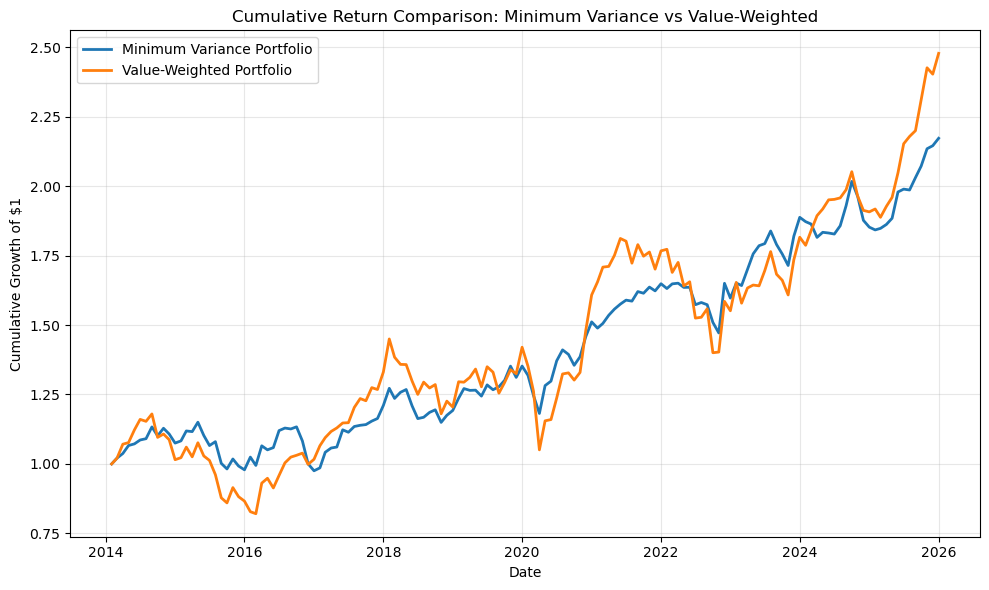


Files saved:
- Data_2026/Comparison_MV_vs_VW.xlsx
- Data_2026/Cumulative_Returns_MV_vs_VW.xlsx
- Data_2026/plots_mv_vs_vw/Cumulative_Return_Comparison_MV_vs_VW.png


In [20]:
print("Starting comparison with the value-weighted benchmark portfolio...")

# --------------------------------------------------------
# 2.3 Comparison with the Value-Weighted Portfolio
# --------------------------------------------------------
# Benchmark formula:
#
#   R^(vw)_(t+1) = sum_i w_(i,t) * R_(i,t+1)
#
# where
#
#   w_(i,t) = Cap_(i,t) / sum_j Cap_(j,t)
#
# and Cap_(i,t) is the market capitalization of firm i
# at the end of month t.
#
# IMPORTANT:
# To avoid look-ahead bias, we must use market caps from month t
# to compute returns in month t+1. Therefore, market caps are lagged by 1 month.

# --------------------------------------------------------
# 1. Load Monthly Market Capitalization Data
# --------------------------------------------------------
mktcap_monthly = load_and_transpose('Data_2026/DS_MV_T_USD_M_2025.xlsx', is_monthly=True)

# Keep only firms from the EM universe
mktcap_em = mktcap_monthly[[isin for isin in valid_em_isins if isin in mktcap_monthly.columns]].copy()

# Align with return dates
mktcap_em = mktcap_em.reindex(returns_em.index)

# Lag market caps by one month to avoid look-ahead bias
mktcap_em_lagged = mktcap_em.shift(1)

# --------------------------------------------------------
# 2. Construct the Out-of-Sample Value-Weighted Portfolio
# --------------------------------------------------------
vw_out_of_sample_returns = []
vw_out_of_sample_dates = []

for holding_year in sorted(valid_investment_sets.keys()):

    # Restrict to the project evaluation period
    if holding_year < 2014 or holding_year > 2025:
        continue

    # Use the same yearly investment set as for the MV portfolio
    valid_isins = valid_investment_sets[holding_year]

    if len(valid_isins) == 0:
        print(f"Holding Year {holding_year}: no eligible firms.")
        continue

    # Monthly returns during the holding year
    holding_returns = returns_em.loc[
        f"{holding_year}-01-01":f"{holding_year}-12-31",
        valid_isins
    ].copy()

    # Lagged market caps used to form the benchmark weights
    holding_caps = mktcap_em_lagged.loc[
        f"{holding_year}-01-01":f"{holding_year}-12-31",
        valid_isins
    ].copy()

    # Keep consistency with your approved workflow
    holding_returns = holding_returns.fillna(0.0)
    holding_caps = holding_caps.fillna(0.0)

    for date, row_returns in holding_returns.iterrows():
        row_caps = holding_caps.loc[date].copy()

        # If no valid market cap information is available, store NaN
        if row_caps.sum() <= 0:
            R_vw = np.nan
        else:
            weights_vw = row_caps / row_caps.sum()
            R_vw = np.dot(weights_vw.values, row_returns.values)

        vw_out_of_sample_returns.append(R_vw)
        vw_out_of_sample_dates.append(date)

    print(f"Holding Year {holding_year}: value-weighted benchmark returns computed.")

# Build final benchmark return series
portfolio_vw_series = pd.Series(vw_out_of_sample_returns, index=vw_out_of_sample_dates)

# Restrict strictly to the evaluation sample
portfolio_vw_series = portfolio_vw_series.loc['2014-01-01':'2025-12-31']

print(f"\nFinal evaluated months for VW portfolio: {len(portfolio_vw_series)} (Expected: 144)")

# --------------------------------------------------------
# 3. Prepare the Minimum Variance Portfolio for Comparison
# --------------------------------------------------------
portfolio_mv_series = portfolio_oos_series.copy()
portfolio_mv_series = portfolio_mv_series.loc['2014-01-01':'2025-12-31']

# Convert both indices to monthly periods for perfect alignment
portfolio_mv_series.index = portfolio_mv_series.index.to_period('M')
portfolio_vw_series.index = portfolio_vw_series.index.to_period('M')

# --------------------------------------------------------
# 4. Load and Align the Risk-Free Rate
# --------------------------------------------------------
rf_df = pd.read_excel('Data_2026/Risk_Free_Rate_2025.xlsx', sheet_name='F-F_Research_Data_Factors')

date_col = rf_df.columns[0]
rate_col = rf_df.columns[1]

rf_df[date_col] = pd.to_datetime(rf_df[date_col].astype(str), format='%Y%m')
rf_df.set_index(date_col, inplace=True)

# Convert from percentage to decimal
rf_series = rf_df[rate_col] / 100.0
rf_series.index = rf_series.index.to_period('M')

rf_mv = rf_series.loc[portfolio_mv_series.index]
rf_vw = rf_series.loc[portfolio_vw_series.index]

mv_excess_returns = portfolio_mv_series - rf_mv
vw_excess_returns = portfolio_vw_series - rf_vw

# --------------------------------------------------------
# 5. Compute Summary Statistics
# --------------------------------------------------------
# Minimum Variance portfolio
mv_ann_avg_return = portfolio_mv_series.mean() * 12
mv_ann_volatility = portfolio_mv_series.std() * np.sqrt(12)
mv_ann_cum_return = (1 + portfolio_mv_series).prod() ** (12 / len(portfolio_mv_series)) - 1
mv_ann_excess_return = mv_excess_returns.mean() * 12
mv_sharp_ratio = mv_ann_excess_return / mv_ann_volatility if mv_ann_volatility != 0 else np.nan
mv_min_return = portfolio_mv_series.min()
mv_max_return = portfolio_mv_series.max()

# Value-Weighted portfolio
vw_ann_avg_return = portfolio_vw_series.mean() * 12
vw_ann_volatility = portfolio_vw_series.std() * np.sqrt(12)
vw_ann_cum_return = (1 + portfolio_vw_series).prod() ** (12 / len(portfolio_vw_series)) - 1
vw_ann_excess_return = vw_excess_returns.mean() * 12
vw_sharp_ratio = vw_ann_excess_return / vw_ann_volatility if vw_ann_volatility != 0 else np.nan
vw_min_return = portfolio_vw_series.min()
vw_max_return = portfolio_vw_series.max()

comparison_stats = pd.DataFrame({
    'Metric': [
        'Annualized average return',
        'Annualized volatility',
        'Annualized cumulative return',
        'Sharpe ratio',
        'Minimum monthly return',
        'Maximum monthly return'
    ],
    'Minimum Variance Portfolio': [
        mv_ann_avg_return,
        mv_ann_volatility,
        mv_ann_cum_return,
        mv_sharp_ratio,
        mv_min_return,
        mv_max_return
    ],
    'Value-Weighted Portfolio': [
        vw_ann_avg_return,
        vw_ann_volatility,
        vw_ann_cum_return,
        vw_sharp_ratio,
        vw_min_return,
        vw_max_return
    ]
})

print("\nSummary statistics comparison:")
display(comparison_stats)

# --------------------------------------------------------
# 6. Plot Cumulative Return Series
# --------------------------------------------------------
mv_plot = portfolio_mv_series.copy()
vw_plot = portfolio_vw_series.copy()

mv_plot.index = mv_plot.index.to_timestamp(how='end')
vw_plot.index = vw_plot.index.to_timestamp(how='end')

mv_cumulative = (1 + mv_plot).cumprod()
vw_cumulative = (1 + vw_plot).cumprod()

mv_cumulative = mv_cumulative / mv_cumulative.iloc[0]
vw_cumulative = vw_cumulative / vw_cumulative.iloc[0]

plt.figure(figsize=(10, 6))
plt.plot(mv_cumulative.index, mv_cumulative.values, linewidth=2, label='Minimum Variance Portfolio')
plt.plot(vw_cumulative.index, vw_cumulative.values, linewidth=2, label='Value-Weighted Portfolio')
plt.title('Cumulative Return Comparison: Minimum Variance vs Value-Weighted')
plt.xlabel('Date')
plt.ylabel('Cumulative Growth of $1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --------------------------------------------------------
# 7. Export Results
# --------------------------------------------------------
output_dir = "Data_2026/plots_mv_vs_vw"
os.makedirs(output_dir, exist_ok=True)

comparison_stats.to_excel('Data_2026/Comparison_MV_vs_VW.xlsx', index=False)

comparison_returns = pd.DataFrame({
    'Minimum_Variance_Return': mv_plot,
    'Value_Weighted_Return': vw_plot,
    'Minimum_Variance_Cumulative': mv_cumulative,
    'Value_Weighted_Cumulative': vw_cumulative
})
comparison_returns.to_excel('Data_2026/Cumulative_Returns_MV_vs_VW.xlsx')

plt.figure(figsize=(10, 6))
plt.plot(mv_cumulative.index, mv_cumulative.values, linewidth=2, label='Minimum Variance Portfolio')
plt.plot(vw_cumulative.index, vw_cumulative.values, linewidth=2, label='Value-Weighted Portfolio')
plt.title('Cumulative Return Comparison: Minimum Variance vs Value-Weighted')
plt.xlabel('Date')
plt.ylabel('Cumulative Growth of $1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_dir}/Cumulative_Return_Comparison_MV_vs_VW.png", dpi=300, bbox_inches='tight')
plt.close()

print("\nFiles saved:")
print("- Data_2026/Comparison_MV_vs_VW.xlsx")
print("- Data_2026/Cumulative_Returns_MV_vs_VW.xlsx")
print(f"- {output_dir}/Cumulative_Return_Comparison_MV_vs_VW.png")

# Part II - Portfolio Allocation with Carbon Emission Reduction

## Allocation with a 50% Reduction in Carbon Emissions

### 3.1 Carbon Emissions

To evaluate the environmental profile of the portfolios, we consider the carbon intensity ($CI_{i,Y}$) of all firms in the investment set. This metric is computed as the total Scope 1 and Scope 2 emissions (in tonnes of CO$_2$ equivalent) per million U.S. dollars of revenue.

At the aggregate portfolio level, we compute two key indicators for each year $Y$:
1.  **Weighted-Average Carbon Intensity (WACI):** The average carbon intensity of the underlying holdings, weighted by their portfolio allocation $\alpha_{i,Y}$.
2.  **Carbon Footprint (CF):** The absolute amount of annual carbon emissions attributed to the investor per million U.S. dollars invested.

The formulas are defined as follows:

$$
WACI_Y^{(p)} = \sum_{i=1}^{N} \alpha_{i,Y} CI_{i,Y} \quad \quad CF_Y^{(p)} = \frac{1}{V_Y} \sum_{i=1}^{N} o_{i,Y} E_{i,Y}
$$

where $o_{i,Y} = V_{i,Y} / Cap_{i,Y}$ measures the fraction of the equity of the firm owned by the portfolio. The term $V_{i,Y} = \alpha_{i,Y} V_Y$ represents the dollar value invested in firm $i$, and $V_Y$ is the total dollar value of the portfolio at the formation date.

To compute the Carbon Footprint dynamically, we simulate the evolution of a starting wealth of $V_{2013} = 1$ million U.S. dollars. We evaluate these metrics for both the out-of-sample Minimum Variance portfolio ($P_{oos}^{(mv)}$) and the Value-Weighted benchmark ($P^{(vw)}$), identifying the top 10 firms that structurally drive the carbon intensity upward.

Starting Section 3.1: Carbon Emissions Analysis...

--- TOP 10 WACI DRIVERS (Value-Weighted Portfolio - Average 2014-2025) ---


,Name,Contrib
ISIN,,
INE733E01010,NTPC,69.1396
INE481G01011,ULTRATECH CEMENT,31.5190
RU0007661625,GAZPROM,23.5022
ZAE000006896,SASOL,18.4078
MYL1961OO001,IOI CORPORATION,11.8115
TW0002330008,TAIWAN SEMICON.MNFG.,10.6635
RU000A0J2Q06,OC ROSNEFT,9.6992
MYL5347OO009,TENAGA NASIONAL,9.5713
INE002A01018,RELIANCE INDUSTRIES,9.4533



--- TOP 10 WACI DRIVERS (Minimum Variance Portfolio - Average 2014-2025) ---


,Name,Contrib
ISIN,,
ID1000106800,SEMEN INDONESIA (PERSERO),88.5984
PEP702101002,ENGIE ENERGIA PERU,58.2516
PEP700511004,ORYGEN PERU,55.1599
TH0637010Y00,RATCH GROUP PCL,50.5225
TH0465010005,ELECTRICITY GENERATING,45.7681
CNE1000002S8,COSCO SHIP.EN.TRSP. 'H',21.8886
TW0002412004,CHUNGHWA TELECOM,19.3476
MYL6033OO004,PETRONAS GAS,17.8638
CLP3615W1037,COLBUN MACHICURA,16.7520



--- ANNUAL CARBON METRICS COMPARISON ---


,WACI_VW,WACI_MV,CF_VW,CF_MV
Year,,,,
2014,572.01,294.28,463.61,156.90
2015,631.71,676.09,582.29,236.64
2016,516.44,486.51,463.96,188.06
2017,627.97,421.26,707.53,271.87
2018,702.10,371.64,664.46,136.37
2019,484.91,885.79,590.58,375.00
2020,587.85,628.22,690.26,275.01
2021,416.44,438.86,673.99,321.84
2022,423.10,669.59,589.68,400.57


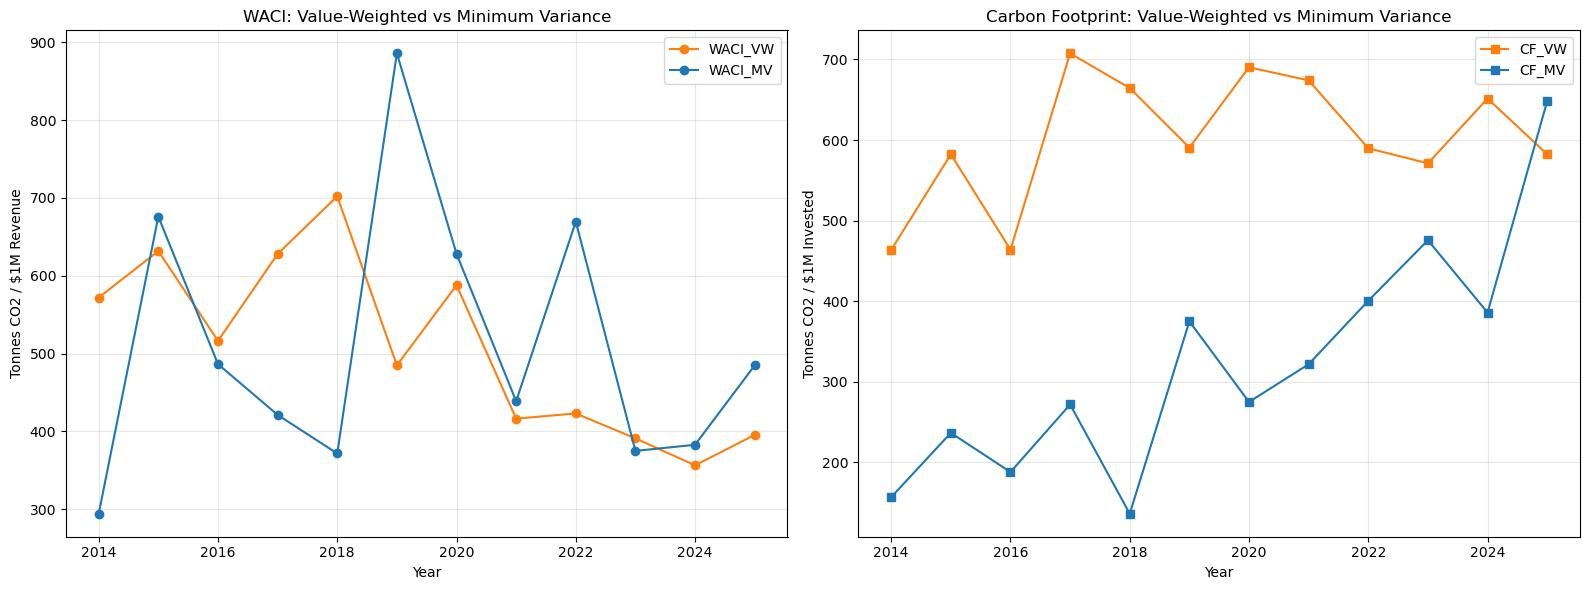


Section 3.1 completed. Plots successfully saved to 'outputs/plots_carbon_metrics'.


In [21]:
print("Starting Section 3.1: Carbon Emissions Analysis...")

# =========================================================================
# 1. Workspace Setup & Static Data Mapping
# =========================================================================
base_output_dir = "outputs"
plots_output_dir = os.path.join(base_output_dir, "plots_carbon_metrics")
os.makedirs(plots_output_dir, exist_ok=True)

# Load static data to map ISIN codes to actual company names for the final reporting
static_names = pd.read_excel("Data_2026/Static_2025.xlsx")
static_names['ISIN'] = static_names['ISIN'].astype(str).str.strip()
isin_to_name = dict(zip(static_names['ISIN'], static_names['NAME']))

# =========================================================================
# 2. Environmental Data Preparation & Imputation
# =========================================================================
# Load annual Revenue and Market Capitalization data
rev_raw = load_and_transpose("Data_2026/DS_REV_Y_2025.xlsx", is_monthly=False)
cap_raw = load_and_transpose("Data_2026/DS_MV_T_USD_Y_2025.xlsx", is_monthly=False)

# Data Imputation: We replace 0.0 values with NaN to ensure the forward-fill method 
# correctly propagates the last reported figures for missing years, as stipulated in the project instructions.
rev_y = rev_raw[valid_em_isins].replace(0.0, np.nan).sort_index().ffill()
cap_y = cap_raw[valid_em_isins].replace(0.0, np.nan).sort_index().ffill()

# Convert Datastream revenue (reported in thousands) to millions of USD
rev_musd_y = rev_y / 1000.0

# Total Emissions: Scope 1 + Scope 2
# A standard addition is performed. If either scope is missing, the result yields NaN,
# strictly enforcing the carbon data availability filter established in Part I.
E_total_y = scope1_em + scope2_em

# Carbon Intensity (CI) calculation: Tonnes CO2 per $1 Million Revenue
CI_y = E_total_y / rev_musd_y

# =========================================================================
# 3. Dynamic Wealth Trajectory (Base Value: $1M in 2013)
# =========================================================================
# Compute compounded annual returns from the out-of-sample monthly series generated in Part I
annual_ret_vw = portfolio_vw_series.groupby(portfolio_vw_series.index.year).apply(lambda x: (1 + x).prod() - 1)
annual_ret_mv = portfolio_oos_series.groupby(portfolio_oos_series.index.year).apply(lambda x: (1 + x).prod() - 1)

# Initialize starting wealth at 1.0 (representing exactly $1,000,000)
wealth_vw = {2013: 1.0}
wealth_mv = {2013: 1.0}

# Step wealth forward dynamically based on realized annual returns
for year in range(2014, 2026):
    wealth_vw[year] = wealth_vw[year-1] * (1 + annual_ret_vw.get(year, 0))
    wealth_mv[year] = wealth_mv[year-1] * (1 + annual_ret_mv.get(year, 0))

# =========================================================================
# 4. Out-of-Sample Carbon Metrics Calculation (2014-2025)
# =========================================================================
carbon_results = []
vw_contributions = []
mv_contributions = []

for holding_year in range(2014, 2026):
    data_year = holding_year - 1
    
    # Ensure the holding year exists in the optimized weights dictionary
    if holding_year not in optimal_weights_mv: continue
    
    # Retrieve the optimized Minimum Variance weights and the corresponding investment set
    weights_mv_all = optimal_weights_mv[holding_year]
    isins = weights_mv_all.index.tolist()
    
    # Extract cross-sectional data for the specific formation year
    E_t = E_total_y.loc[data_year, isins]
    CI_t = CI_y.loc[data_year, isins]
    Cap_t = cap_y.loc[data_year, isins]
    
    # Data Integrity Check: Restrict the cross-section to firms with valid carbon intensity 
    # and market capitalization data. Firms persistently missing data are safely excluded.
    valid_mask = CI_t.notna() & Cap_t.notna() & (Cap_t > 0)
    valid_isins = CI_t[valid_mask].index.tolist()
    
    if len(valid_isins) == 0: continue
    
    # Renormalize weights to maintain full 100% investment exposure
    w_mv = weights_mv_all[valid_isins]
    w_mv = w_mv / w_mv.sum() 
    
    w_vw = Cap_t[valid_isins] / Cap_t[valid_isins].sum()
    
    # --- Weighted-Average Carbon Intensity (WACI) ---
    WACI_vw = np.sum(w_vw * CI_t[valid_isins])
    WACI_mv = np.sum(w_mv * CI_t[valid_isins])
    
    # --- Carbon Footprint (CF) ---
    V_vw = wealth_vw[data_year]
    V_mv = wealth_mv[data_year]
    
    # Calculate ownership fraction: o_i = (Weight_i * Portfolio_Wealth) / Market_Cap_i
    o_i_vw = (w_vw * V_vw) / Cap_t[valid_isins]
    o_i_mv = (w_mv * V_mv) / Cap_t[valid_isins]
    
    # Total CF: (1 / Portfolio_Wealth) * Sum(o_i * E_i)
    CF_vw = (1 / V_vw) * np.sum(o_i_vw * E_t[valid_isins])
    CF_mv = (1 / V_mv) * np.sum(o_i_mv * E_t[valid_isins])
    
    # Store annual aggregate metrics
    carbon_results.append({
        'Year': holding_year,
        'WACI_VW': WACI_vw, 'WACI_MV': WACI_mv,
        'CF_VW': CF_vw, 'CF_MV': CF_mv
    })
    
    # Store firm-level WACI contributions for the Top 10 Drivers analysis.
    # Note: Using `.values` strips the Pandas index, preventing grouping ambiguities downstream.
    vw_contributions.append(pd.DataFrame({
        'ISIN': valid_isins, 
        'Contrib': (w_vw * CI_t[valid_isins]).values
    }))
    mv_contributions.append(pd.DataFrame({
        'ISIN': valid_isins, 
        'Contrib': (w_mv * CI_t[valid_isins]).values
    }))

# Compile the final metrics into a structured DataFrame
df_metrics = pd.DataFrame(carbon_results).set_index('Year')

# =========================================================================
# 5. Top 10 Drivers Analysis & Visualizations
# =========================================================================
num_years = 12

# Aggregate historical contributions, reset the index to resolve ambiguities, 
# and compute the true historical average impact over the 12-year horizon.
top10_vw = pd.concat(vw_contributions).reset_index(drop=True).groupby('ISIN').sum() / num_years
top10_vw = top10_vw.sort_values('Contrib', ascending=False).head(10)
top10_vw['Name'] = [isin_to_name.get(i, i) for i in top10_vw.index]

top10_mv = pd.concat(mv_contributions).reset_index(drop=True).groupby('ISIN').sum() / num_years
top10_mv = top10_mv.sort_values('Contrib', ascending=False).head(10)
top10_mv['Name'] = [isin_to_name.get(i, i) for i in top10_mv.index]

# Output Display
print("\n--- TOP 10 WACI DRIVERS (Value-Weighted Portfolio - Average 2014-2025) ---")
display(top10_vw[['Name', 'Contrib']].round(4))

print("\n--- TOP 10 WACI DRIVERS (Minimum Variance Portfolio - Average 2014-2025) ---")
display(top10_mv[['Name', 'Contrib']].round(4))

print("\n--- ANNUAL CARBON METRICS COMPARISON ---")
display(df_metrics.round(2))

# Plotting the evolution of carbon metrics
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Updated colors: tab:orange for VW, tab:blue for MV
df_metrics[['WACI_VW', 'WACI_MV']].plot(ax=ax[0], marker='o', color=['tab:orange', 'tab:blue'], title="WACI: Value-Weighted vs Minimum Variance")
ax[0].set_ylabel("Tonnes CO2 / $1M Revenue")
ax[0].grid(True, alpha=0.3)

df_metrics[['CF_VW', 'CF_MV']].plot(ax=ax[1], marker='s', color=['tab:orange', 'tab:blue'], title="Carbon Footprint: Value-Weighted vs Minimum Variance")
ax[1].set_ylabel("Tonnes CO2 / $1M Invested")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(plots_output_dir, "Carbon_Metrics_Comparison.png"), dpi=300)
plt.show()

print(f"\nSection 3.1 completed. Plots successfully saved to '{plots_output_dir}'.")

### 3.2 Long-only portfolio with a carbon footprint objective

We now construct an optimal long-only portfolio with a carbon footprint 50% below the carbon footprint of the baseline Minimum Variance portfolio $P_{oos}^{(mv)}$ determined in Section 2.2.

For every year $Y$ in the sample, we compute the optimal weights by minimizing the portfolio variance subject to a strict carbon footprint constraint. This is achieved by solving the following optimization problem:

$$
\begin{aligned}
\min_{\{\alpha_Y\}} \quad & \sigma_{p,Y}^2 = \alpha_Y' \Sigma_Y \alpha_Y \\
\text{s.t.} \quad & CF_Y^{(p)} \le 0.5 \times CF_Y^{(P_{oos}^{(mv)})} \\
& \alpha_Y' e = 1 \\
& \alpha_{i,Y} \ge 0 \quad \text{for all } i
\end{aligned}
$$

**Methodological Note:** As previously defined, the Carbon Footprint is computed using the formula $CF_Y = \frac{1}{V_Y} \sum o_{i,Y} E_{i,Y}$, where $o_{i,Y} = \alpha_{i,Y} V_Y / Cap_{i,Y}$. When substituting $o_{i,Y}$ into the constraint, the portfolio wealth $V_Y$ mathematically cancels out. This simplifies the environmental constraint into a linear function of the weights:
$$\sum_{i=1}^{N} \alpha_{i,Y} \left( \frac{E_{i,Y}}{Cap_{i,Y}} \right) \le 0.5 \times CF_Y^{(P_{oos}^{(mv)})}$$

We call this new constrained portfolio $P_{oos}^{(mv)}(0.5)$. We then compute the out-of-sample monthly returns, tracking the weight drift dynamically. Finally, we plot the cumulative return series of both strategies, compare their summary statistics, and provide details on the main changes regarding the portfolio's composition (such as explicitly excluded and under-weighted firms).

Starting Section 3.2: Long-only portfolio with a carbon footprint objective...

--- Summary Statistics Comparison ---


,Metric,Minimum Variance Portfolio,Value-Weighted Portfolio,Minimum Variance (50% CF)
0,Annualized average return,0.0672,0.0822,0.0652
1,Annualized volatility,0.1048,0.1557,0.1003
2,Annualized cumulative return,0.0636,0.0724,0.0619
3,Sharpe ratio,0.4746,0.4157,0.4756
4,Minimum monthly return,-0.0759,-0.1671,-0.0676
5,Maximum monthly return,0.1213,0.1341,0.1193



--- Carbon Metrics: Baseline MV vs MV (50% Reduction) ---


,WACI_MV,WACI_MV_05,CF_MV,CF_MV_05
Year,,,,
2014,294.28,187.79,156.90,78.45
2015,676.09,279.22,236.64,118.32
2016,486.51,263.27,188.06,94.03
2017,421.26,184.41,271.87,135.93
2018,371.64,158.56,136.37,68.19
2019,885.79,413.99,375.00,187.50
2020,628.22,274.11,275.01,137.51
2021,438.86,325.56,321.84,160.92
2022,669.59,527.67,400.57,200.29


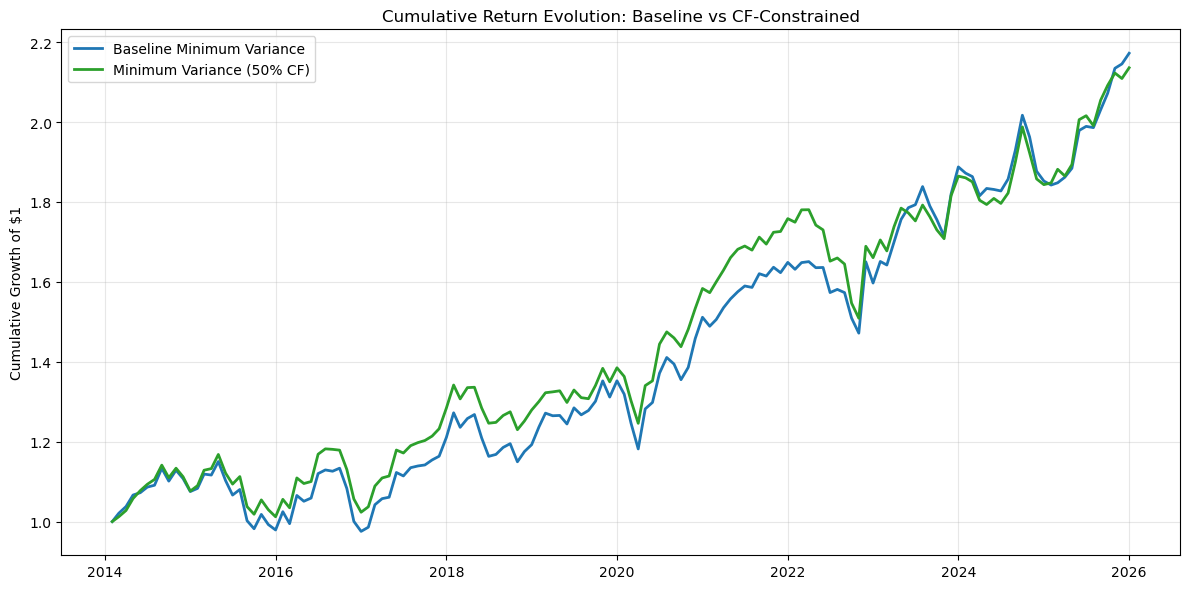

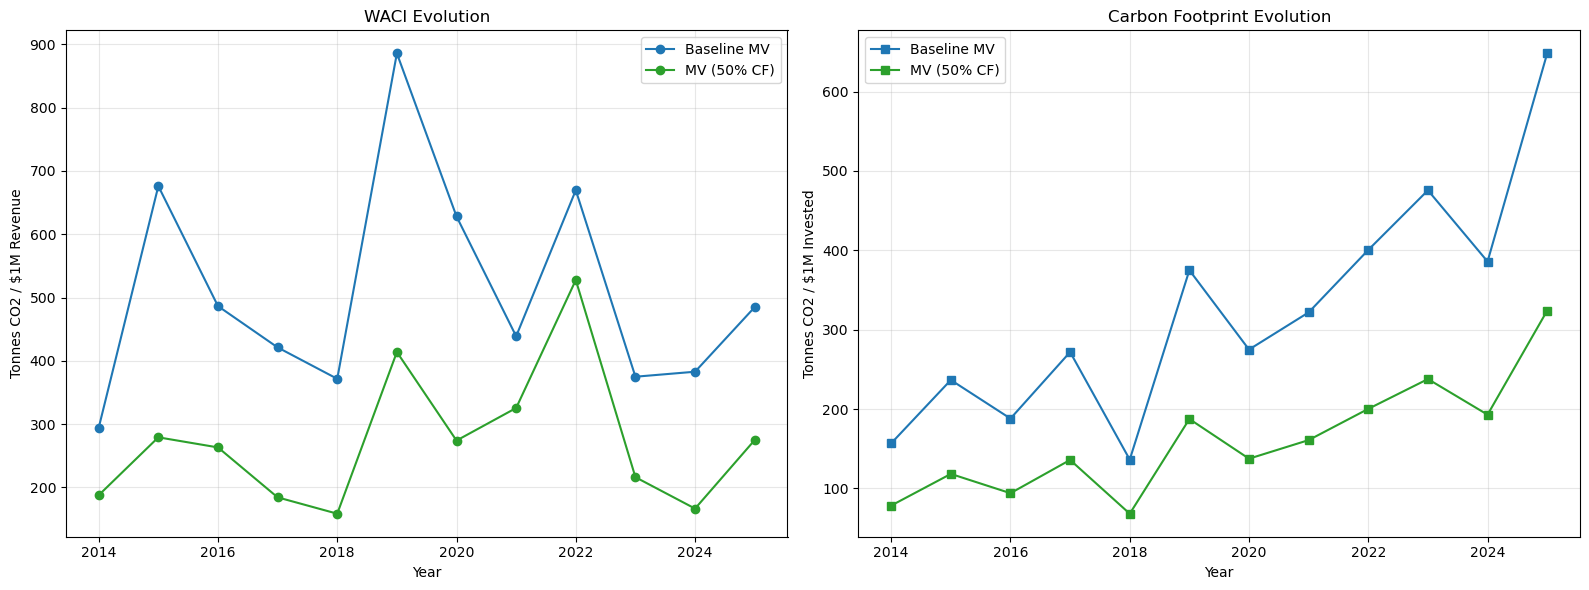


--- EXCLUDED FIRMS: Top 5 firms completely dropped from the portfolio ---


,ISIN,Name,Years_Excluded
50,TW0003045001,TAIWAN MOBILE,5
51,TW0004904008,FAR EASTONE TELECOM.,4
26,MYL4707OO005,NESTLE (MALAYSIA),4
16,INE752E01010,POWER GRID CORPORATION OF INDIA,3
52,TW0009917005,TAIWAN SECOM,3



--- HISTORICAL AVERAGE: Top 5 Under-Weighted Firms ---


,Name,Baseline_MV,MV_05,Shift
MYL4162OO003,BRIT.AMER.TOB.(MALAYSIA),0.1457,0.0569,-0.0888
TW0003045001,TAIWAN MOBILE,0.0929,0.0279,-0.0650
TH0268010Z03,ADVANCED INFO SER.,0.0360,0.0126,-0.0234
BRCPFEACNOR0,CPFL ENERGIA ON,0.0171,0.0000,-0.0171
MYL4863OO006,TELEKOM MALAYSIA,0.0424,0.0262,-0.0163



--- HISTORICAL AVERAGE: Top 5 Over-Weighted Firms ---


,Name,Baseline_MV,MV_05,Shift
TW0002412004,CHUNGHWA TELECOM,0.2545,0.3158,0.0614
MYL4065OO008,PPB GROUP,0.0036,0.0085,0.0049
TH0450010Y08,THAI UNION GROUP,0.0265,0.0314,0.0048
TW0002357001,ASUSTEK COMPUTER,0.0009,0.0055,0.0046
MYL5235SS008,KLCC PROPERTY HOLDINGS STAPLED UNITS,0.0123,0.0167,0.0044


In [22]:
print("Starting Section 3.2: Long-only portfolio with a carbon footprint objective...")

# =========================================================================
# 1. Setup & Data Initialization
# =========================================================================
base_output_dir = "outputs"
plots_output_dir = os.path.join(base_output_dir, "plots_carbon_metrics")
analysis_output_dir = os.path.join(base_output_dir, "composition_analysis")
os.makedirs(plots_output_dir, exist_ok=True)
os.makedirs(analysis_output_dir, exist_ok=True)

# Static names mapping
static_names = pd.read_excel("Data_2026/Static_2025.xlsx")
static_names['ISIN'] = static_names['ISIN'].astype(str).str.strip()
isin_to_name = dict(zip(static_names['ISIN'], static_names['NAME']))

# Dictionaries to store out-of-sample data
optimal_weights_mv_05 = {}
returns_mv_05 = []
dates_mv_05 = []
yearly_shifts = [] # Stores year-by-year composition changes

# =========================================================================
# 2. Constrained Optimization Loop (Holding Years 2014-2025)
# =========================================================================
for holding_year in range(2014, 2026):
    data_year = holding_year - 1
    
    if holding_year not in sigma_estimates or holding_year not in optimal_weights_mv:
        continue
        
    w_mv_baseline_all = optimal_weights_mv[holding_year]
    Sigma_Y_all = sigma_estimates[holding_year]
    isins = w_mv_baseline_all.index.tolist()
    
    E_t = E_total_y.loc[data_year, isins]
    CI_t = CI_y.loc[data_year, isins]
    Cap_t = cap_y.loc[data_year, isins]
    
    # Restrict to valid firms
    valid_mask = CI_t.notna() & Cap_t.notna() & (Cap_t > 0)
    valid_isins = CI_t[valid_mask].index.tolist()
    n_assets = len(valid_isins)
    
    if n_assets == 0: continue
        
    Sigma_sub = Sigma_Y_all.loc[valid_isins, valid_isins].to_numpy()
    
    w_mv_base = w_mv_baseline_all[valid_isins].to_numpy()
    w_mv_base = w_mv_base / np.sum(w_mv_base) 
    
    c_vector = (E_t[valid_isins] / Cap_t[valid_isins]).to_numpy()
    CF_baseline_Y = np.dot(w_mv_base, c_vector)
    CF_target_Y = 0.5 * CF_baseline_Y
    
    # ---------------------------------------------------------------------
    # Optimization Setup
    # ---------------------------------------------------------------------
    def portfolio_variance(w, cov_matrix):
        return (w.T @ cov_matrix @ w) * 10000
        
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0},
        {'type': 'ineq', 'fun': lambda w: (CF_target_Y - np.dot(w, c_vector)) / max(CF_baseline_Y, 1e-6)}
    ]
    bounds = tuple((0.0, 1.0) for _ in range(n_assets))
    initial_w = np.ones(n_assets) / n_assets
    
    res = minimize(portfolio_variance, initial_w, args=(Sigma_sub,), 
                   method='SLSQP', bounds=bounds, constraints=constraints)
                   
    if not res.success:
        sorted_indices = np.argsort(c_vector)
        fallback_w = np.zeros(n_assets)
        half_n = max(1, n_assets // 2)
        fallback_w[sorted_indices[:half_n]] = 1.0 / half_n
        w_opt = fallback_w
    else:
        w_opt = np.round(res.x, 6)
        w_opt = w_opt / np.sum(w_opt)
        
    optimal_weights_mv_05[holding_year] = pd.Series(w_opt, index=valid_isins)
    
    # Store year-by-year shifts (Friend's approach)
    year_shift_df = pd.DataFrame({
        'Year': holding_year,
        'ISIN': valid_isins,
        'Name': [isin_to_name.get(i, i) for i in valid_isins],
        'Weight_MV': w_mv_base,
        'Weight_MV_CF50': w_opt,
        'Delta_Weight': w_opt - w_mv_base
    })
    yearly_shifts.append(year_shift_df)
    
    # Ex-Post Performance Tracking
    start_date_holding = f"{holding_year}-01-01"
    end_date_holding = f"{holding_year}-12-31"
    holding_returns = returns_em.loc[start_date_holding:end_date_holding, valid_isins].fillna(0.0)
    
    current_w = w_opt.copy()
    
    for date, row in holding_returns.iterrows():
        R_tk = row.values
        R_p = np.dot(current_w, R_tk)
        
        returns_mv_05.append(R_p)
        dates_mv_05.append(date)
        
        current_w = current_w * (1 + R_tk) / (1 + R_p)
        current_w = current_w / np.sum(current_w)

portfolio_mv_05_series = pd.Series(returns_mv_05, index=dates_mv_05).loc['2014-01-01':'2025-12-31']
portfolio_mv_05_series.index = portfolio_mv_05_series.index.to_period('M')

# Compile and export Year-by-Year Table
df_yearly_shifts = pd.concat(yearly_shifts, ignore_index=True)
df_yearly_shifts.to_excel(os.path.join(analysis_output_dir, "Year_by_Year_Composition_Shifts.xlsx"), index=False)

# =========================================================================
# 3. Portfolio Characteristics & Comparison
# =========================================================================
rf_mv_05 = rf_series.loc[portfolio_mv_05_series.index]
mv_05_excess_returns = portfolio_mv_05_series - rf_mv_05

ann_ret_05 = portfolio_mv_05_series.mean() * 12
ann_vol_05 = portfolio_mv_05_series.std() * np.sqrt(12)
ann_cum_05 = (1 + portfolio_mv_05_series).prod() ** (12 / len(portfolio_mv_05_series)) - 1
sharpe_ratio_05 = (mv_05_excess_returns.mean() * 12) / ann_vol_05 if ann_vol_05 != 0 else np.nan
min_ret_05 = portfolio_mv_05_series.min()
max_ret_05 = portfolio_mv_05_series.max()

# Update stats and fix the Sharpe typo
comparison_stats['Minimum Variance (50% CF)'] = [
    ann_ret_05, ann_vol_05, ann_cum_05, sharpe_ratio_05, min_ret_05, max_ret_05
]

print("\n--- Summary Statistics Comparison ---")
display(comparison_stats.round(4))

# =========================================================================
# 4. Ex-Post Carbon Metrics Evolution
# =========================================================================
annual_ret_mv_05 = portfolio_mv_05_series.groupby(portfolio_mv_05_series.index.year).apply(lambda x: (1 + x).prod() - 1)
wealth_mv_05 = {2013: 1.0}
for year in range(2014, 2026):
    wealth_mv_05[year] = wealth_mv_05[year-1] * (1 + annual_ret_mv_05.get(year, 0))

metrics_05 = []

for holding_year in range(2014, 2026):
    data_year = holding_year - 1
    w_05 = optimal_weights_mv_05[holding_year]
    isins = w_05.index.tolist()
    E_t = E_total_y.loc[data_year, isins]
    CI_t = CI_y.loc[data_year, isins]
    Cap_t = cap_y.loc[data_year, isins]
    
    WACI_05 = np.sum(w_05 * CI_t)
    V_05 = wealth_mv_05[data_year]
    o_i_05 = (w_05 * V_05) / Cap_t
    CF_05 = (1 / V_05) * np.sum(o_i_05 * E_t)
    
    metrics_05.append({'Year': holding_year, 'WACI_MV_05': WACI_05, 'CF_MV_05': CF_05})

df_metrics_05 = pd.DataFrame(metrics_05).set_index('Year')
df_all_metrics = df_metrics.join(df_metrics_05)

print("\n--- Carbon Metrics: Baseline MV vs MV (50% Reduction) ---")
display(df_all_metrics[['WACI_MV', 'WACI_MV_05', 'CF_MV', 'CF_MV_05']].round(2))

# =========================================================================
# 5. Visualizations: Cumulative Returns & Environmental Impact
# =========================================================================
mv_05_plot = portfolio_mv_05_series.copy()
mv_05_plot.index = mv_05_plot.index.to_timestamp(how='end')
mv_05_cumulative = (1 + mv_05_plot).cumprod()
mv_05_cumulative = mv_05_cumulative / mv_05_cumulative.iloc[0]

# Plot 1: Cumulative Returns
plt.figure(figsize=(12, 6))
plt.plot(mv_cumulative.index, mv_cumulative.values, linewidth=2, label='Baseline Minimum Variance', color='tab:blue')
plt.plot(mv_05_cumulative.index, mv_05_cumulative.values, linewidth=2, linestyle='-', label='Minimum Variance (50% CF)', color='tab:green')
plt.title('Cumulative Return Evolution: Baseline vs CF-Constrained')
plt.ylabel('Cumulative Growth of $1')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(plots_output_dir, "Strategy_3_2_CumulativeReturn.png"), dpi=300)
plt.show()

# Plot 2: Carbon Metrics
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

df_all_metrics[['WACI_MV', 'WACI_MV_05']].plot(ax=ax[0], marker='o', color=['tab:blue', 'tab:green'])
ax[0].set_title('WACI Evolution')
ax[0].set_ylabel('Tonnes CO2 / $1M Revenue')
ax[0].grid(True, alpha=0.3)
ax[0].legend(['Baseline MV', 'MV (50% CF)'])

df_all_metrics[['CF_MV', 'CF_MV_05']].plot(ax=ax[1], marker='s', color=['tab:blue', 'tab:green'])
ax[1].set_title('Carbon Footprint Evolution')
ax[1].set_ylabel('Tonnes CO2 / $1M Invested')
ax[1].grid(True, alpha=0.3)
ax[1].legend(['Baseline MV', 'MV (50% CF)'])

plt.tight_layout()
plt.savefig(os.path.join(plots_output_dir, "Strategy_3_2_CarbonEvolution.png"), dpi=300)
plt.show()

# =========================================================================
# 6. Composition Changes (Exclusions, Over/Under-weights)
# =========================================================================
# 6.1 Excluded Firms Analysis (Dropped completely to meet constraints)
excluded_mask = (df_yearly_shifts['Weight_MV'] > 0.001) & (df_yearly_shifts['Weight_MV_CF50'] < 0.00001)
excluded_firms_df = df_yearly_shifts[excluded_mask]
most_excluded = excluded_firms_df.groupby(['ISIN', 'Name']).size().reset_index(name='Years_Excluded')
most_excluded = most_excluded.sort_values(by='Years_Excluded', ascending=False).head(5)

print("\n--- EXCLUDED FIRMS: Top 5 firms completely dropped from the portfolio ---")
display(most_excluded)

# 6.2 Historical Average Allocation Shifts
num_years = 12
avg_weights_base = pd.DataFrame(optimal_weights_mv).fillna(0).sum(axis=1) / num_years
avg_weights_05 = pd.DataFrame(optimal_weights_mv_05).fillna(0).sum(axis=1) / num_years

weight_diff = pd.DataFrame({
    'Baseline_MV': avg_weights_base,
    'MV_05': avg_weights_05,
    'Shift': avg_weights_05 - avg_weights_base
}).fillna(0)
weight_diff['Name'] = [isin_to_name.get(i, i) for i in weight_diff.index]

top_underweighted = weight_diff.sort_values(by='Shift').head(5)
top_overweighted = weight_diff.sort_values(by='Shift', ascending=False).head(5)

print("\n--- HISTORICAL AVERAGE: Top 5 Under-Weighted Firms ---")
display(top_underweighted[['Name', 'Baseline_MV', 'MV_05', 'Shift']].round(4))

print("\n--- HISTORICAL AVERAGE: Top 5 Over-Weighted Firms ---")
display(top_overweighted[['Name', 'Baseline_MV', 'MV_05', 'Shift']].round(4))

3.3

Starting Section 3.3: Tracking error minimization with 50% carbon reduction...
  Holding Year 2014: optimization successful, CF = 231.8062 <= target 231.8062
  Holding Year 2015: optimization successful, CF = 291.1471 <= target 291.1471
  Holding Year 2016: optimization successful, CF = 231.9803 <= target 231.9803
  Holding Year 2017: optimization successful, CF = 353.7666 <= target 353.7666
  Holding Year 2018: optimization successful, CF = 332.2312 <= target 332.2312
  Holding Year 2019: optimization successful, CF = 295.2890 <= target 295.2890
  Holding Year 2020: optimization successful, CF = 345.1300 <= target 345.1300
  Holding Year 2021: optimization successful, CF = 336.9969 <= target 336.9969
  Holding Year 2022: optimization successful, CF = 294.8413 <= target 294.8413
  Holding Year 2023: optimization successful, CF = 285.5409 <= target 285.5409
  Holding Year 2024: optimization successful, CF = 325.7342 <= target 325.7342
  Holding Year 2025: optimization successful, CF = 2

,Metric,P^(vw)_oos,P^(vw)_oos(0.5)
0,Annualized average return,0.0822,0.0901
1,Annualized volatility,0.1557,0.1610
2,Annualized cumulative return,0.0724,0.0800
3,Sharpe ratio,0.4157,0.4512
4,Minimum monthly return,-0.1671,-0.1672
5,Maximum monthly return,0.1341,0.1419
6,Realized tracking error (ann.),0.0000,0.0185



--- Optimization Diagnostics ---


,Data_Year,Number_of_Firms,CF_Benchmark_VW,CF_Target_50pct,CF_TE_Portfolio,WACI_Benchmark_VW,WACI_TE_Portfolio,Carbon_Slack,Weight_Sum,Min_Weight,Tracking_Error_ExAnte,Solver_Message
Holding_Year,,,,,,,,,,,,
2014,2013,245,463.6123,231.8062,231.8062,572.0070,272.5376,0.0,1.0,0.0,0.0,Optimization terminated successfully
2015,2014,266,582.2943,291.1471,291.1471,631.7098,297.2001,0.0,1.0,0.0,0.0,Optimization terminated successfully
2016,2015,294,463.9605,231.9803,231.9803,516.4361,269.3982,-0.0,1.0,0.0,0.0,Optimization terminated successfully
2017,2016,332,707.5332,353.7666,353.7666,627.9708,388.8472,0.0,1.0,0.0,0.0,Optimization terminated successfully
2018,2017,378,664.4625,332.2312,332.2312,702.0969,499.7953,0.0,1.0,0.0,0.0,Optimization terminated successfully
2019,2018,413,590.5780,295.2890,295.2890,484.9121,362.1035,-0.0,1.0,0.0,0.0,Optimization terminated successfully
2020,2019,461,690.2600,345.1300,345.1300,587.8497,334.7825,0.0,1.0,0.0,0.0,Optimization terminated successfully
2021,2020,501,673.9937,336.9969,336.9969,416.4369,338.2593,0.0,1.0,0.0,0.0,Optimization terminated successfully
2022,2021,538,589.6827,294.8413,294.8413,423.0991,355.8775,0.0,1.0,0.0,0.0,Optimization terminated successfully



--- Carbon Metrics: VW Benchmark vs TE Portfolio ---


,WACI_VW,WACI_TE_05,CF_VW,CF_TE_05
Year,,,,
2014,572.01,272.54,463.61,231.81
2015,631.71,297.20,582.29,291.15
2016,516.44,269.40,463.96,231.98
2017,627.97,388.85,707.53,353.77
2018,702.10,499.80,664.46,332.23
2019,484.91,362.10,590.58,295.29
2020,587.85,334.78,690.26,345.13
2021,416.44,338.26,673.99,337.00
2022,423.10,355.88,589.68,294.84


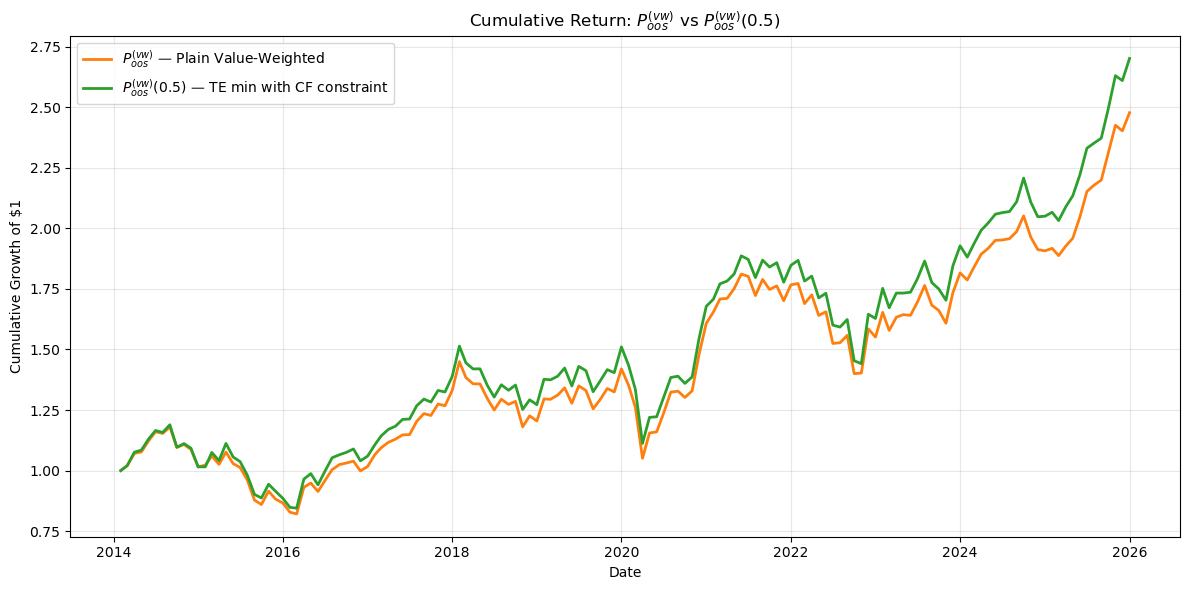

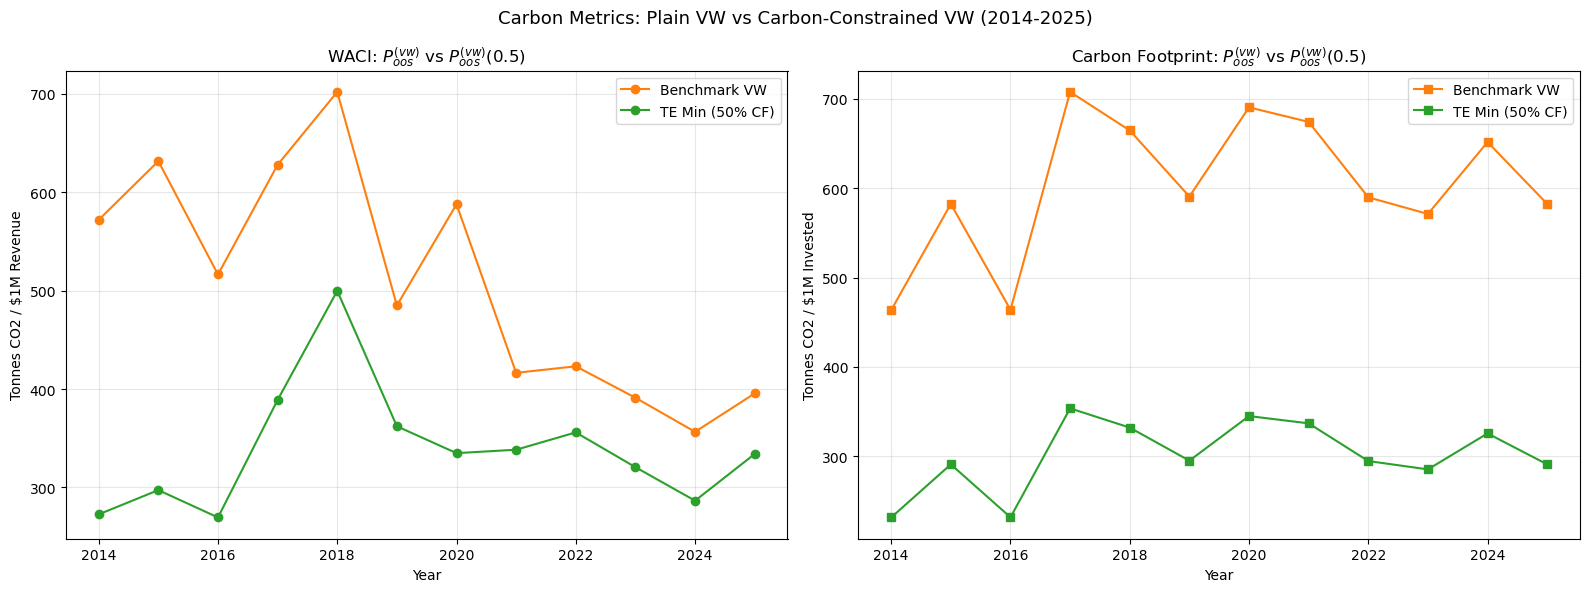


Section 3.3 completed. Files saved in: outputs/tracking_error_analysis


In [23]:
print("Starting Section 3.3: Tracking error minimization with 50% carbon reduction...")

try:
    from IPython.display import display
except ImportError:
    def display(x):
        print(x)

# --------------------------------------------------------
# 1. Setup
# --------------------------------------------------------
base_output_dir  = "outputs"
plots_output_dir = os.path.join(base_output_dir, "plots_carbon_metrics")
output_dir_33    = os.path.join(base_output_dir, "tracking_error_analysis")
os.makedirs(plots_output_dir, exist_ok=True)
os.makedirs(output_dir_33,    exist_ok=True)

tracking_error_weights        = {}
tracking_error_returns        = []
tracking_error_dates          = []
tracking_error_yearly_stats   = []
tracking_error_carbon_metrics = []

solver_tol = 1e-8

# --------------------------------------------------------
# 2. Helper functions
# --------------------------------------------------------
def regularize_covariance(Sigma, eps=1e-10):
    Sigma = np.asarray(Sigma, dtype=float)
    Sigma = 0.5 * (Sigma + Sigma.T)
    Sigma = Sigma + eps * np.eye(Sigma.shape[0])
    return Sigma

def tracking_error_variance(w, w_bench, Sigma):
    diff = w - w_bench
    return float(diff.T @ Sigma @ diff)

# --------------------------------------------------------
# 3. Solve the tracking-error minimization year by year
# --------------------------------------------------------
for holding_year in range(2014, 2026):
    data_year = holding_year - 1

    if holding_year not in sigma_estimates:
        print(f"Holding Year {holding_year}: covariance matrix missing, skipping.")
        continue

    if holding_year not in valid_investment_sets:
        print(f"Holding Year {holding_year}: investment set missing, skipping.")
        continue

    candidate_isins = list(valid_investment_sets[holding_year])

    if len(candidate_isins) == 0:
        print(f"Holding Year {holding_year}: no eligible firms.")
        continue

    # Keep only firms available across all data objects
    sigma_cols      = sigma_estimates[holding_year].columns
    candidate_isins = [
        isin for isin in candidate_isins
        if isin in sigma_cols
        and isin in E_total_y.columns
        and isin in CI_y.columns
        and isin in cap_y.columns
        and isin in returns_em.columns
    ]

    if len(candidate_isins) == 0:
        print(f"Holding Year {holding_year}: no common firms across data objects, skipping.")
        continue

    Sigma_Y = sigma_estimates[holding_year].loc[candidate_isins, candidate_isins].copy()
    E_t     = E_total_y.loc[data_year, candidate_isins].copy()
    CI_t    = CI_y.loc[data_year, candidate_isins].copy()
    Cap_t   = cap_y.loc[data_year, candidate_isins].copy()

    # Keep only firms with valid emissions, CI and positive market cap
    valid_mask        = E_t.notna() & CI_t.notna() & Cap_t.notna() & (Cap_t > 0)
    valid_isins_final = E_t[valid_mask].index.tolist()

    if len(valid_isins_final) < 2:
        print(f"Holding Year {holding_year}: not enough firms with valid data, skipping.")
        continue

    # Remove firms with NaN in their covariance row/column
    Sigma_sub_df      = Sigma_Y.loc[valid_isins_final, valid_isins_final].copy()
    good_assets       = Sigma_sub_df.columns[Sigma_sub_df.notna().all()].tolist()
    valid_isins_final = good_assets

    if len(valid_isins_final) < 2:
        print(f"Holding Year {holding_year}: covariance matrix invalid after filtering, skipping.")
        continue

    Sigma_sub = regularize_covariance(
        Sigma_Y.loc[valid_isins_final, valid_isins_final].to_numpy(dtype=float)
    )
    E_sub   = E_t.loc[valid_isins_final].to_numpy(dtype=float)
    CI_sub  = CI_t.loc[valid_isins_final].to_numpy(dtype=float)
    Cap_sub = Cap_t.loc[valid_isins_final].to_numpy(dtype=float)

    # --------------------------------------------------
    # Benchmark: value-weighted portfolio
    # w_{i,Y} = Cap_{i,Y} / Cap_Y
    # --------------------------------------------------
    w_vw = Cap_sub / Cap_sub.sum()

    # Carbon loading: E_i / Cap_i  (V_Y cancels in CF formula)
    cf_firm = E_sub / Cap_sub

    # CF of VW benchmark: (1/Cap_Y) * sum(E_i) — PDF formula exactly
    CF_vw_Y     = float(np.dot(w_vw, cf_firm))
    CF_target_Y = 0.5 * CF_vw_Y

    # Feasibility check — skip year gracefully instead of crashing
    if float(np.min(cf_firm)) > CF_target_Y + solver_tol:
        print(f"Holding Year {holding_year}: 50% CF target is infeasible, skipping.")
        continue

    # --------------------------------------------------
    # Constraints
    # --------------------------------------------------
    constraints = [
        {'type': 'eq',
         'fun': lambda w: np.sum(w) - 1.0},
        {'type': 'ineq',
         'fun': lambda w, cf=cf_firm, target=CF_target_Y: target - np.dot(w, cf)}
    ]

    bounds = [(0.0, 1.0) for _ in range(len(valid_isins_final))]

    # --------------------------------------------------
    # Run optimization — two attempts for robustness
    # First attempt: VW weights (natural starting point)
    # --------------------------------------------------
    result = minimize(
        fun=tracking_error_variance,
        x0=w_vw.copy(),
        args=(w_vw, Sigma_sub),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-12, 'maxiter': 2000, 'disp': False}
    )

    # Second attempt: equal weights if VW start fails
    if not result.success:
        result = minimize(
            fun=tracking_error_variance,
            x0=np.ones(len(valid_isins_final)) / len(valid_isins_final),
            args=(w_vw, Sigma_sub),
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'ftol': 1e-12, 'maxiter': 2000, 'disp': False}
        )

    # Skip year gracefully if both attempts fail
    if not result.success:
        print(f"Holding Year {holding_year}: optimization failed -> {result.message}")
        continue

    w_opt = np.clip(result.x, 0.0, 1.0)
    w_opt = w_opt / w_opt.sum()

    # Solution validation — warn and skip instead of crashing
    weight_sum   = float(np.sum(w_opt))
    min_weight   = float(np.min(w_opt))
    carbon_slack = float(CF_target_Y - np.dot(w_opt, cf_firm))

    if abs(weight_sum - 1.0) > 1e-6 or min_weight < -solver_tol or carbon_slack < -1e-6:
        print(f"  Holding Year {holding_year}: invalid solution "
              f"(sum={weight_sum:.8f}, min_w={min_weight:.3e}, "
              f"carbon_slack={carbon_slack:.3e}), skipping.")
        continue

    tracking_error_weights[holding_year] = pd.Series(w_opt, index=valid_isins_final)

    # Ex-ante diagnostics
    te_variance_Y = tracking_error_variance(w_opt, w_vw, Sigma_sub)
    te_Y          = float(np.sqrt(max(te_variance_Y, 0.0)))
    CF_te_Y       = float(np.dot(w_opt, cf_firm))
    WACI_vw_Y     = float(np.dot(w_vw, CI_sub))
    WACI_te_Y     = float(np.dot(w_opt, CI_sub))

    tracking_error_yearly_stats.append({
        'Holding_Year':          holding_year,
        'Data_Year':             data_year,
        'Number_of_Firms':       len(valid_isins_final),
        'CF_Benchmark_VW':       CF_vw_Y,
        'CF_Target_50pct':       CF_target_Y,
        'CF_TE_Portfolio':       CF_te_Y,
        'WACI_Benchmark_VW':     WACI_vw_Y,
        'WACI_TE_Portfolio':     WACI_te_Y,
        'Carbon_Slack':          carbon_slack,
        'Weight_Sum':            weight_sum,
        'Min_Weight':            min_weight,
        'Tracking_Error_ExAnte': te_Y,
        'Solver_Message':        result.message
    })

    tracking_error_carbon_metrics.append({
        'Year':       holding_year,
        'WACI_TE_05': WACI_te_Y,
        'CF_TE_05':   CF_te_Y
    })

    # --------------------------------------------------
    # Out-of-sample monthly performance with weight drift
    # --------------------------------------------------
    holding_returns = returns_em.loc[
        f"{holding_year}-01-01":f"{holding_year}-12-31",
        valid_isins_final
    ].copy()

    if holding_returns.empty:
        print(f"Holding Year {holding_year}: no monthly returns available, skipping.")
        continue

    holding_returns  = holding_returns.fillna(0.0)
    current_w_te     = w_opt.copy()

    for date, row_returns in holding_returns.iterrows():
        asset_returns       = row_returns.to_numpy(dtype=float)
        te_portfolio_return = float(np.dot(current_w_te, asset_returns))

        tracking_error_returns.append(te_portfolio_return)
        tracking_error_dates.append(date)

        current_w_te = current_w_te * (1.0 + asset_returns) / (1.0 + te_portfolio_return)
        current_w_te = current_w_te / current_w_te.sum()

    print(f"  Holding Year {holding_year}: optimization successful, "
          f"CF = {CF_te_Y:.4f} <= target {CF_target_Y:.4f}")

# --------------------------------------------------------
# 4. Build final return series
# --------------------------------------------------------
portfolio_te_05_series       = pd.Series(tracking_error_returns, index=tracking_error_dates)
portfolio_te_05_series       = portfolio_te_05_series.loc['2014-01-01':'2025-12-31']
portfolio_te_05_series.index = portfolio_te_05_series.index.to_period('M')

# Use official VW benchmark from Part I
benchmark_vw_33_series       = portfolio_vw_series.copy()
benchmark_vw_33_series       = benchmark_vw_33_series.loc['2014':'2025']

# Align both series
aligned_33 = pd.concat([
    portfolio_te_05_series.rename('TE'),
    benchmark_vw_33_series.rename('VW')
], axis=1).dropna()

portfolio_te_05_series = aligned_33['TE']
benchmark_vw_33_series = aligned_33['VW']

rf_te = rf_series.reindex(aligned_33.index).ffill().bfill()

print(f"\nP^(vw)_oos(0.5): {len(portfolio_te_05_series)} months (expected 144)")

# --------------------------------------------------------
# 5. Summary Statistics
# --------------------------------------------------------
te_excess_returns    = portfolio_te_05_series - rf_te
vw_excess_returns_33 = benchmark_vw_33_series - rf_te

te_ann_avg_return  = portfolio_te_05_series.mean() * 12
te_ann_volatility  = portfolio_te_05_series.std()  * np.sqrt(12)
te_ann_cum_return  = (1 + portfolio_te_05_series).prod() ** (12 / len(portfolio_te_05_series)) - 1
te_sharpe_ratio    = (te_excess_returns.mean() * 12) / te_ann_volatility \
                     if te_ann_volatility != 0 else np.nan
te_min_return      = portfolio_te_05_series.min()
te_max_return      = portfolio_te_05_series.max()

vw_ann_avg_return_33  = benchmark_vw_33_series.mean() * 12
vw_ann_volatility_33  = benchmark_vw_33_series.std()  * np.sqrt(12)
vw_ann_cum_return_33  = (1 + benchmark_vw_33_series).prod() ** (12 / len(benchmark_vw_33_series)) - 1
vw_sharpe_ratio_33    = (vw_excess_returns_33.mean() * 12) / vw_ann_volatility_33 \
                        if vw_ann_volatility_33 != 0 else np.nan
vw_min_return_33      = benchmark_vw_33_series.min()
vw_max_return_33      = benchmark_vw_33_series.max()

realized_te_annualized = (portfolio_te_05_series - benchmark_vw_33_series).std() * np.sqrt(12)

comparison_stats_33 = pd.DataFrame({
    'Metric': [
        'Annualized average return',
        'Annualized volatility',
        'Annualized cumulative return',
        'Sharpe ratio',
        'Minimum monthly return',
        'Maximum monthly return',
        'Realized tracking error (ann.)'
    ],
    'P^(vw)_oos': [
        vw_ann_avg_return_33, vw_ann_volatility_33, vw_ann_cum_return_33,
        vw_sharpe_ratio_33,   vw_min_return_33,     vw_max_return_33,
        0.0
    ],
    'P^(vw)_oos(0.5)': [
        te_ann_avg_return, te_ann_volatility, te_ann_cum_return,
        te_sharpe_ratio,   te_min_return,     te_max_return,
        realized_te_annualized
    ]
})

print("\nSummary Statistics: P^(vw)_oos vs P^(vw)_oos(0.5):")
display(comparison_stats_33.round(4))

# --------------------------------------------------------
# 6. Carbon Metrics Table
# --------------------------------------------------------
df_tracking_error_diag = pd.DataFrame(tracking_error_yearly_stats).set_index('Holding_Year')
df_metrics_te          = pd.DataFrame(tracking_error_carbon_metrics).set_index('Year')
df_metrics_33          = df_metrics.join(df_metrics_te, how='left')

for col in ['WACI_VW', 'CF_VW', 'WACI_TE_05', 'CF_TE_05']:
    if col not in df_metrics_33.columns:
        df_metrics_33[col] = np.nan

print("\n--- Optimization Diagnostics ---")
display(df_tracking_error_diag.round(4))

print("\n--- Carbon Metrics: VW Benchmark vs TE Portfolio ---")
display(df_metrics_33[['WACI_VW', 'WACI_TE_05', 'CF_VW', 'CF_TE_05']].round(2))

# --------------------------------------------------------
# 7. Cumulative Return Plot
# --------------------------------------------------------
te_plot    = portfolio_te_05_series.copy()
vw_plot_33 = benchmark_vw_33_series.copy()

te_plot.index    = te_plot.index.to_timestamp(how='end')
vw_plot_33.index = vw_plot_33.index.to_timestamp(how='end')

te_cumulative    = (1 + te_plot).cumprod()
vw_cumulative_33 = (1 + vw_plot_33).cumprod()

te_cumulative    = te_cumulative    / te_cumulative.iloc[0]
vw_cumulative_33 = vw_cumulative_33 / vw_cumulative_33.iloc[0]

plt.figure(figsize=(12, 6))
plt.plot(vw_cumulative_33.index, vw_cumulative_33.values, linewidth=2,
         label='$P^{(vw)}_{oos}$ — Plain Value-Weighted',           color='tab:orange')
plt.plot(te_cumulative.index,    te_cumulative.values,    linewidth=2,
         label='$P^{(vw)}_{oos}(0.5)$ — TE min with CF constraint', color='tab:green')
plt.title('Cumulative Return: $P^{(vw)}_{oos}$ vs $P^{(vw)}_{oos}(0.5)$')
plt.xlabel('Date')
plt.ylabel('Cumulative Growth of $1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(plots_output_dir, "Strategy_3_3_CumulativeReturn.png"), dpi=300)
plt.show()

# --------------------------------------------------------
# 8. Carbon Metrics Plot
# --------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

df_metrics_33[['WACI_VW', 'WACI_TE_05']].plot(ax=ax[0], marker='o',
                                                color=['tab:orange', 'tab:green'])
ax[0].set_title('WACI: $P^{(vw)}_{oos}$ vs $P^{(vw)}_{oos}(0.5)$')
ax[0].set_ylabel('Tonnes CO2 / $1M Revenue')
ax[0].legend(['Benchmark VW', 'TE Min (50% CF)'])
ax[0].grid(True, alpha=0.3)

df_metrics_33[['CF_VW', 'CF_TE_05']].plot(ax=ax[1], marker='s',
                                            color=['tab:orange', 'tab:green'])
ax[1].set_title('Carbon Footprint: $P^{(vw)}_{oos}$ vs $P^{(vw)}_{oos}(0.5)$')
ax[1].set_ylabel('Tonnes CO2 / $1M Invested')
ax[1].legend(['Benchmark VW', 'TE Min (50% CF)'])
ax[1].grid(True, alpha=0.3)

plt.suptitle('Carbon Metrics: Plain VW vs Carbon-Constrained VW (2014-2025)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(plots_output_dir, "Strategy_3_3_CarbonEvolution.png"), dpi=300)
plt.show()

# --------------------------------------------------------
# 9. Export results
# --------------------------------------------------------
comparison_stats_33.to_excel(
    os.path.join(output_dir_33, "Section_3_3_Summary_Statistics.xlsx"), index=False
)

pd.DataFrame({
    'Tracking_Error_Portfolio_Return':     te_plot,
    'Value_Weighted_Benchmark_Return':     vw_plot_33,
    'Tracking_Error_Portfolio_Cumulative': te_cumulative,
    'Value_Weighted_Benchmark_Cumulative': vw_cumulative_33
}).to_excel(os.path.join(output_dir_33, "Section_3_3_Cumulative_Returns_TE_vs_VW.xlsx"))

df_tracking_error_diag.to_excel(
    os.path.join(output_dir_33, "Section_3_3_Optimization_Diagnostics.xlsx")
)

df_metrics_33.to_excel(
    os.path.join(output_dir_33, "Section_3_3_Carbon_Metrics.xlsx")
)

weights_export = []
for y, s in tracking_error_weights.items():
    tmp          = s.rename('Weight_TE_05').reset_index()
    tmp.columns  = ['ISIN', 'Weight_TE_05']
    tmp.insert(0, 'Holding_Year', y)
    weights_export.append(tmp)

if len(weights_export) > 0:
    pd.concat(weights_export, ignore_index=True).to_excel(
        os.path.join(output_dir_33, "Section_3_3_Weights.xlsx"), index=False
    )

print(f"\nSection 3.3 completed. Files saved in: {output_dir_33}")

Starting Section 4: Portfolio Allocation with a Net Zero Objective...
CF_VW at Y0=2013 (anchor): 463.6123 tonnes CO2 / million USD

Net Zero CF Targets:
  2014: 417.2511  (90.0% of baseline)
  2015: 375.5260  (81.0% of baseline)
  2016: 337.9734  (72.9% of baseline)
  2017: 304.1760  (65.6% of baseline)
  2018: 273.7584  (59.0% of baseline)
  2019: 246.3826  (53.1% of baseline)
  2020: 221.7443  (47.8% of baseline)
  2021: 199.5699  (43.0% of baseline)
  2022: 179.6129  (38.7% of baseline)
  2023: 161.6516  (34.9% of baseline)
  2024: 145.4865  (31.4% of baseline)
  2025: 130.9378  (28.2% of baseline)
  Holding Year 2014: CF = 417.2511 <= NZ target 417.2511 (reduction: 10.0%)
  Holding Year 2015: CF = 375.5260 <= NZ target 375.5260 (reduction: 35.5%)
  Holding Year 2016: CF = 337.9734 <= NZ target 337.9734 (reduction: 27.2%)
  Holding Year 2017: CF = 304.1760 <= NZ target 304.1760 (reduction: 57.0%)
  Holding Year 2018: CF = 273.7584 <= NZ target 273.7584 (reduction: 58.8%)
  Holding Y

,Metric,P^(vw)_oos,P^(vw)_oos(NZ)
0,Annualized average return,0.0822,0.0916
1,Annualized volatility,0.1557,0.1614
2,Annualized cumulative return,0.0724,0.0816
3,Sharpe ratio,0.4157,0.4595
4,Minimum monthly return,-0.1671,-0.1666
5,Maximum monthly return,0.1341,0.1433
6,Realized tracking error (ann.),0.0000,0.0189



--- Year-by-Year Net Zero Diagnostics ---


,NZ_Target,CF_VW,CF_NZ_Portfolio,Carbon_Reduction_%,WACI_VW,WACI_NZ_Portfolio,Tracking_Error_ExAnte,Carbon_Slack,N_Firms
Holding_Year,,,,,,,,,
2014,417.2511,463.6123,417.2511,10.0000,572.0070,519.1227,0.0,0.0,245
2015,375.5260,582.2943,375.5260,35.5092,631.7098,382.0399,0.0,0.0,266
2016,337.9734,463.9605,337.9734,27.1547,516.4361,381.8766,0.0,0.0,294
2017,304.1760,707.5332,304.1760,57.0089,627.9708,348.6831,0.0,0.0,332
2018,273.7584,664.4625,273.7584,58.8000,702.0969,451.7769,0.0,0.0,378
2019,246.3826,590.5780,246.3826,58.2811,484.9121,311.4193,0.0,0.0,413
2020,221.7443,690.2600,221.7443,67.8752,587.8497,247.4793,0.0,-0.0,461
2021,199.5699,673.9937,199.5699,70.3899,416.4369,242.8837,0.0,0.0,501
2022,179.6129,589.6827,179.6129,69.5408,423.0991,270.5326,0.0,0.0,538



--- Section 4.2 Comparison: All 3 VW Portfolios ---


,$P^{(vw)}_{oos}$,$P^{(vw)}_{oos}(0.5)$,$P^{(vw)}_{oos}(NZ)$
Annualized average return,0.0822,0.0901,0.0916
Annualized volatility,0.1557,0.1610,0.1614
Annualized cumulative return,0.0724,0.0800,0.0816
Sharpe ratio,0.4157,0.4512,0.4595
Minimum monthly return,-0.1671,-0.1672,-0.1666
Maximum monthly return,0.1341,0.1419,0.1433



--- Carbon Metrics: All Portfolios ---


,WACI_VW,WACI_TE_05,WACI_NZ,CF_VW,CF_TE_05,CF_NZ
Year,,,,,,
2014,572.01,272.54,519.12,463.61,231.81,417.25
2015,631.71,297.20,382.04,582.29,291.15,375.53
2016,516.44,269.40,381.88,463.96,231.98,337.97
2017,627.97,388.85,348.68,707.53,353.77,304.18
2018,702.10,499.80,451.78,664.46,332.23,273.76
2019,484.91,362.10,311.42,590.58,295.29,246.38
2020,587.85,334.78,247.48,690.26,345.13,221.74
2021,416.44,338.26,242.88,673.99,337.00,199.57
2022,423.10,355.88,270.53,589.68,294.84,179.61


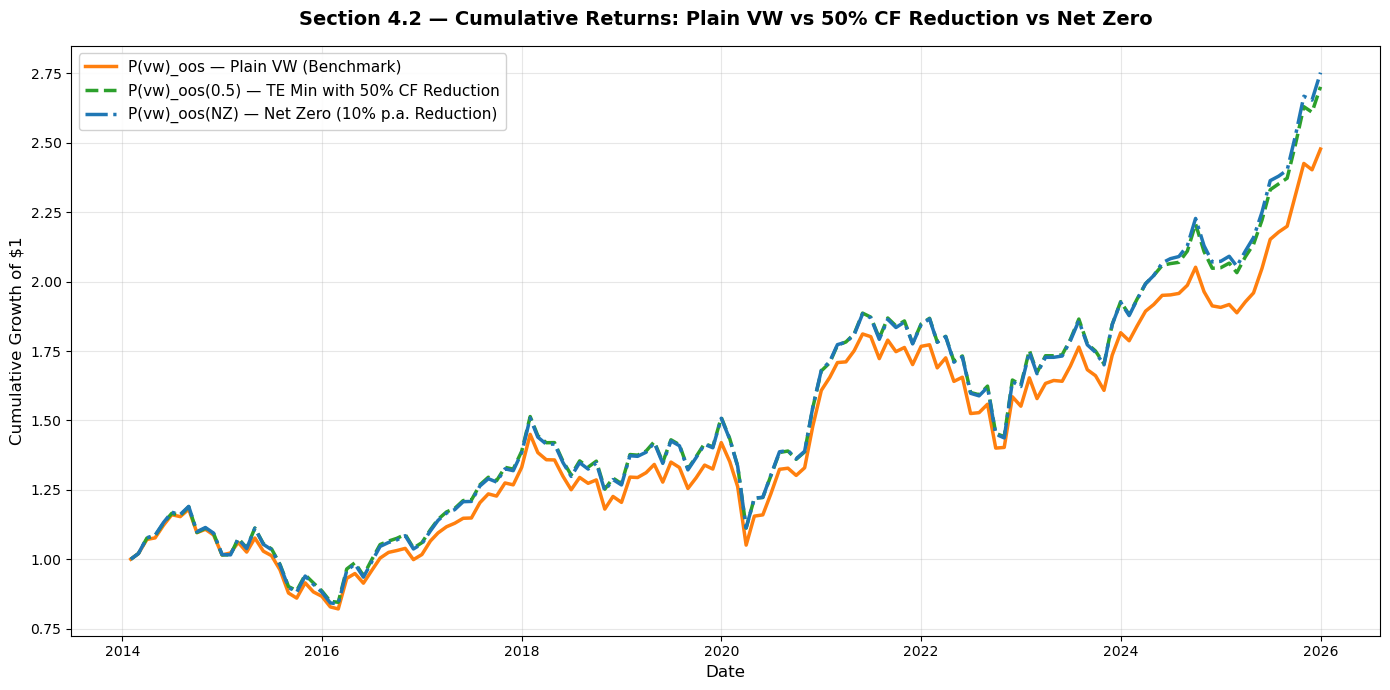

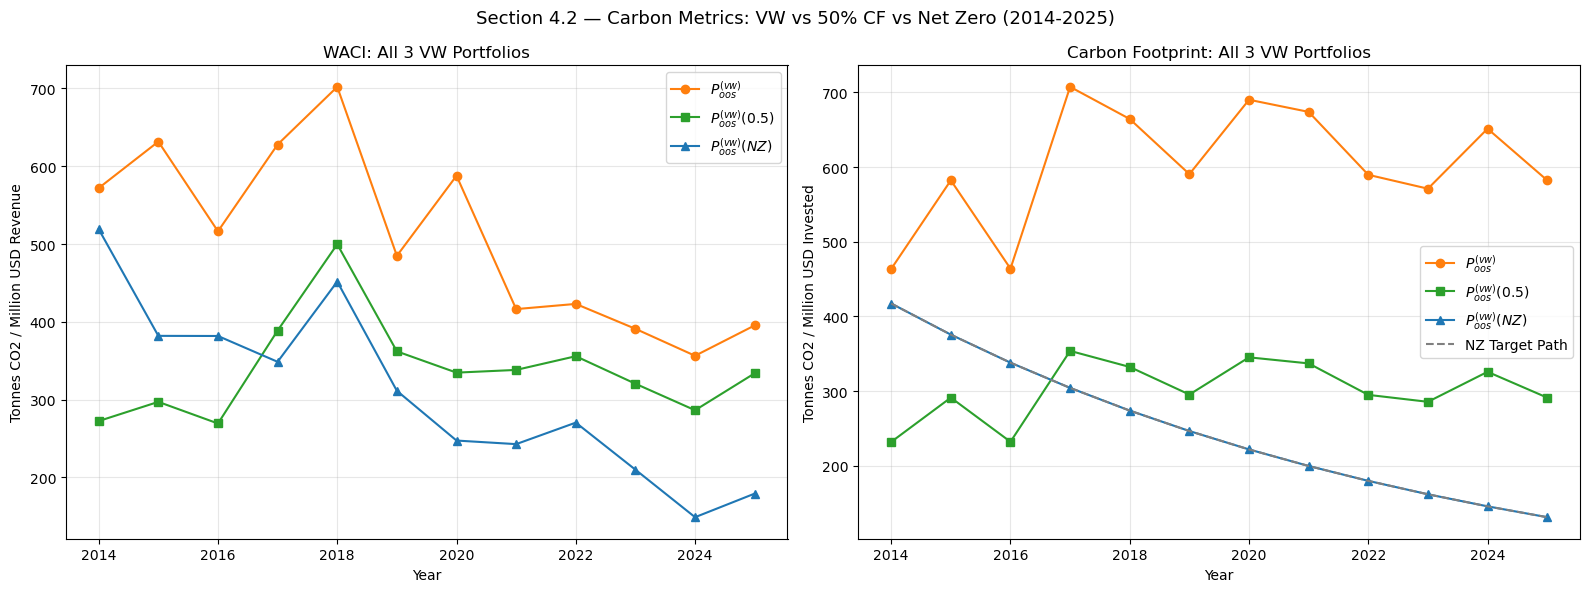


Section 4 completed. Files saved in: outputs/net_zero_analysis


In [24]:
print("Starting Section 4: Portfolio Allocation with a Net Zero Objective...")

try:
    from IPython.display import display
except ImportError:
    def display(x):
        print(x)

# --------------------------------------------------------
# 1. Setup
# --------------------------------------------------------
base_output_dir  = "outputs"
plots_output_dir = os.path.join(base_output_dir, "plots_carbon_metrics")
output_dir_4     = os.path.join(base_output_dir, "net_zero_analysis")
os.makedirs(plots_output_dir, exist_ok=True)
os.makedirs(output_dir_4,     exist_ok=True)

# --------------------------------------------------------
# 2. Net Zero CF Target Computation
# --------------------------------------------------------
# From the PDF:
#
#   CF^(p)_Y <= (1 - theta)^(Y - Y0 + 1) * CF^(P(vw))_Y0
#
#   theta = 10% per year
#   Y0    = 2013
#   CF^(P(vw))_Y0 = carbon footprint of VW portfolio at Y0 = 2013
#
# This means:
#   - Year 2014: target = (0.9)^1  * CF_VW_2013
#   - Year 2015: target = (0.9)^2  * CF_VW_2013
#   - ...
#   - Year 2025: target = (0.9)^12 * CF_VW_2013
#
# The baseline CF_VW_2013 is computed from the investment set
# at the end of 2013 (formation year for holding year 2014).
# We use the same formula as 3.3: CF = sum(E_i) / sum(Cap_i)

theta = 0.10
Y0    = 2013

# Compute CF_VW at Y0 = 2013 from the investment set
# This is the anchor for all future net zero targets
if Y0 in valid_investment_sets and Y0 in cap_y.index and Y0 in E_total_y.index:

    nz_isins_2013 = [
        isin for isin in valid_investment_sets[2014]   # investment set used for 2014
        if isin in cap_y.columns
        and isin in E_total_y.columns
        and not np.isnan(cap_y.loc[Y0, isin])
        and cap_y.loc[Y0, isin] > 0
        and not np.isnan(E_total_y.loc[Y0, isin])
    ]

    cap_2013      = cap_y.loc[Y0, nz_isins_2013].values
    em_2013       = E_total_y.loc[Y0, nz_isins_2013].values
    CF_VW_Y0      = float(em_2013.sum() / cap_2013.sum())

    print(f"CF_VW at Y0=2013 (anchor): {CF_VW_Y0:.4f} tonnes CO2 / million USD")
else:
    raise RuntimeError("Cannot compute CF_VW_Y0 — check valid_investment_sets and cap_y for year 2013.")

# Pre-compute net zero targets for each holding year
nz_targets = {}
for holding_year in range(2014, 2026):
    exponent          = holding_year - Y0       # Y - Y0 (no +1 because Y0=2013, first year=2014)
    nz_targets[holding_year] = (1 - theta) ** exponent * CF_VW_Y0

print("\nNet Zero CF Targets:")
for y, t in nz_targets.items():
    print(f"  {y}: {t:.4f}  ({(1-theta)**(y-Y0)*100:.1f}% of baseline)")

# --------------------------------------------------------
# 3. Helper functions (same as 3.3)
# --------------------------------------------------------
def regularize_covariance(Sigma, eps=1e-10):
    Sigma = np.asarray(Sigma, dtype=float)
    Sigma = 0.5 * (Sigma + Sigma.T)
    Sigma = Sigma + eps * np.eye(Sigma.shape[0])
    return Sigma

def tracking_error_variance(w, w_bench, Sigma):
    diff = w - w_bench
    return float(diff.T @ Sigma @ diff)

# --------------------------------------------------------
# 4. Net Zero Optimization Loop (Holding Years 2014-2025)
# --------------------------------------------------------
# Same structure as 3.3 — minimize TE vs VW
# ONLY the CF constraint changes: target is now the net zero path
# instead of 50% of the current year VW carbon footprint

nz_weights        = {}
nz_returns        = []
nz_dates          = []
nz_yearly_stats   = []
nz_carbon_metrics = []

solver_tol = 1e-8

for holding_year in range(2014, 2026):
    data_year  = holding_year - 1
    nz_target  = nz_targets[holding_year]

    if holding_year not in sigma_estimates:
        print(f"Holding Year {holding_year}: covariance matrix missing, skipping.")
        continue

    if holding_year not in valid_investment_sets:
        print(f"Holding Year {holding_year}: investment set missing, skipping.")
        continue

    candidate_isins = list(valid_investment_sets[holding_year])

    if len(candidate_isins) == 0:
        print(f"Holding Year {holding_year}: no eligible firms.")
        continue

    # Keep only firms available across all data objects
    sigma_cols      = sigma_estimates[holding_year].columns
    candidate_isins = [
        isin for isin in candidate_isins
        if isin in sigma_cols
        and isin in E_total_y.columns
        and isin in CI_y.columns
        and isin in cap_y.columns
        and isin in returns_em.columns
    ]

    if len(candidate_isins) == 0:
        print(f"Holding Year {holding_year}: no common firms across data objects, skipping.")
        continue

    Sigma_Y = sigma_estimates[holding_year].loc[candidate_isins, candidate_isins].copy()
    E_t     = E_total_y.loc[data_year, candidate_isins].copy()
    CI_t    = CI_y.loc[data_year, candidate_isins].copy()
    Cap_t   = cap_y.loc[data_year, candidate_isins].copy()

    valid_mask        = E_t.notna() & CI_t.notna() & Cap_t.notna() & (Cap_t > 0)
    valid_isins_final = E_t[valid_mask].index.tolist()

    if len(valid_isins_final) < 2:
        print(f"Holding Year {holding_year}: not enough firms with valid data, skipping.")
        continue

    # Remove firms with NaN in covariance rows/columns
    Sigma_sub_df      = Sigma_Y.loc[valid_isins_final, valid_isins_final].copy()
    good_assets       = Sigma_sub_df.columns[Sigma_sub_df.notna().all()].tolist()
    valid_isins_final = good_assets

    if len(valid_isins_final) < 2:
        print(f"Holding Year {holding_year}: covariance matrix invalid after filtering, skipping.")
        continue

    Sigma_sub = regularize_covariance(
        Sigma_Y.loc[valid_isins_final, valid_isins_final].to_numpy(dtype=float)
    )
    E_sub   = E_t.loc[valid_isins_final].to_numpy(dtype=float)
    CI_sub  = CI_t.loc[valid_isins_final].to_numpy(dtype=float)
    Cap_sub = Cap_t.loc[valid_isins_final].to_numpy(dtype=float)

    # VW benchmark weights
    w_vw    = Cap_sub / Cap_sub.sum()

    # Carbon loading: E_i / Cap_i
    cf_firm = E_sub / Cap_sub

    # --------------------------------------------------
    # NET ZERO constraint: CF^(p)_Y <= nz_target
    # (1-theta)^(Y-Y0) * CF_VW_Y0
    # --------------------------------------------------
    # Feasibility check
    if float(np.min(cf_firm)) > nz_target + solver_tol:
        print(f"Holding Year {holding_year}: net zero target {nz_target:.4f} is infeasible "
              f"(min firm CF = {np.min(cf_firm):.4f}), skipping.")
        continue

    # Constraints — same structure as 3.3, only target changes
    constraints = [
        {'type': 'eq',
         'fun': lambda w: np.sum(w) - 1.0},
        {'type': 'ineq',
         'fun': lambda w, cf=cf_firm, target=nz_target: target - np.dot(w, cf)}
    ]

    bounds = [(0.0, 1.0) for _ in range(len(valid_isins_final))]

    # First attempt: VW weights
    result = minimize(
        fun=tracking_error_variance,
        x0=w_vw.copy(),
        args=(w_vw, Sigma_sub),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-12, 'maxiter': 2000, 'disp': False}
    )

    # Second attempt: equal weights
    if not result.success:
        result = minimize(
            fun=tracking_error_variance,
            x0=np.ones(len(valid_isins_final)) / len(valid_isins_final),
            args=(w_vw, Sigma_sub),
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'ftol': 1e-12, 'maxiter': 2000, 'disp': False}
        )

    if not result.success:
        print(f"Holding Year {holding_year}: optimization failed -> {result.message}")
        continue

    w_opt = np.clip(result.x, 0.0, 1.0)
    w_opt = w_opt / w_opt.sum()

    # Solution validation
    weight_sum   = float(np.sum(w_opt))
    min_weight   = float(np.min(w_opt))
    carbon_slack = float(nz_target - np.dot(w_opt, cf_firm))

    if abs(weight_sum - 1.0) > 1e-6 or min_weight < -solver_tol or carbon_slack < -1e-6:
        print(f"  Holding Year {holding_year}: invalid solution, skipping.")
        continue

    nz_weights[holding_year] = pd.Series(w_opt, index=valid_isins_final)

    # Diagnostics
    te_variance_Y = tracking_error_variance(w_opt, w_vw, Sigma_sub)
    te_Y          = float(np.sqrt(max(te_variance_Y, 0.0)))
    CF_nz_Y       = float(np.dot(w_opt, cf_firm))
    CF_vw_Y       = float(np.dot(w_vw, cf_firm))
    WACI_nz_Y     = float(np.dot(w_opt, CI_sub))
    WACI_vw_Y     = float(np.dot(w_vw, CI_sub))

    nz_yearly_stats.append({
        'Holding_Year':          holding_year,
        'NZ_Target':             nz_target,
        'CF_VW':                 CF_vw_Y,
        'CF_NZ_Portfolio':       CF_nz_Y,
        'Carbon_Reduction_%':    (1 - CF_nz_Y / CF_vw_Y) * 100 if CF_vw_Y > 0 else np.nan,
        'WACI_VW':               WACI_vw_Y,
        'WACI_NZ_Portfolio':     WACI_nz_Y,
        'Tracking_Error_ExAnte': te_Y,
        'Carbon_Slack':          carbon_slack,
        'N_Firms':               len(valid_isins_final)
    })

    nz_carbon_metrics.append({
        'Year':    holding_year,
        'WACI_NZ': WACI_nz_Y,
        'CF_NZ':   CF_nz_Y
    })

    # --------------------------------------------------
    # Out-of-sample monthly returns with weight drift
    # --------------------------------------------------
    holding_returns = returns_em.loc[
        f"{holding_year}-01-01":f"{holding_year}-12-31",
        valid_isins_final
    ].copy()

    if holding_returns.empty:
        print(f"Holding Year {holding_year}: no monthly returns, skipping.")
        continue

    holding_returns = holding_returns.fillna(0.0)
    current_w_nz    = w_opt.copy()

    for date, row_returns in holding_returns.iterrows():
        asset_returns      = row_returns.to_numpy(dtype=float)
        nz_portfolio_return = float(np.dot(current_w_nz, asset_returns))

        nz_returns.append(nz_portfolio_return)
        nz_dates.append(date)

        current_w_nz = current_w_nz * (1.0 + asset_returns) / (1.0 + nz_portfolio_return)
        current_w_nz = current_w_nz / current_w_nz.sum()

    print(f"  Holding Year {holding_year}: CF = {CF_nz_Y:.4f} "
          f"<= NZ target {nz_target:.4f} "
          f"(reduction: {(1-CF_nz_Y/CF_vw_Y)*100:.1f}%)")

# --------------------------------------------------------
# 5. Build final return series
# --------------------------------------------------------
portfolio_nz_series       = pd.Series(nz_returns, index=nz_dates)
portfolio_nz_series       = portfolio_nz_series.loc['2014-01-01':'2025-12-31']
portfolio_nz_series.index = portfolio_nz_series.index.to_period('M')

# Align with official VW benchmark from Part I
benchmark_vw_nz = portfolio_vw_series.copy().loc['2014':'2025']

aligned_nz = pd.concat([
    portfolio_nz_series.rename('NZ'),
    benchmark_vw_nz.rename('VW')
], axis=1).dropna()

portfolio_nz_series = aligned_nz['NZ']
benchmark_vw_nz     = aligned_nz['VW']
rf_nz               = rf_series.reindex(aligned_nz.index).ffill().bfill()

print(f"\nP^(vw)_oos(NZ): {len(portfolio_nz_series)} months (expected 144)")

# --------------------------------------------------------
# 6. Section 4.1 — Summary Statistics
# --------------------------------------------------------
nz_excess  = portfolio_nz_series - rf_nz
vw_excess  = benchmark_vw_nz     - rf_nz

nz_ann_avg_return = portfolio_nz_series.mean() * 12
nz_ann_volatility = portfolio_nz_series.std()  * np.sqrt(12)
nz_ann_cum_return = (1 + portfolio_nz_series).prod() ** (12 / len(portfolio_nz_series)) - 1
nz_sharpe_ratio   = (nz_excess.mean() * 12) / nz_ann_volatility \
                    if nz_ann_volatility != 0 else np.nan
nz_min_return     = portfolio_nz_series.min()
nz_max_return     = portfolio_nz_series.max()

vw_ann_avg_return = benchmark_vw_nz.mean() * 12
vw_ann_volatility = benchmark_vw_nz.std()  * np.sqrt(12)
vw_ann_cum_return = (1 + benchmark_vw_nz).prod() ** (12 / len(benchmark_vw_nz)) - 1
vw_sharpe_ratio   = (vw_excess.mean() * 12) / vw_ann_volatility \
                    if vw_ann_volatility != 0 else np.nan
vw_min_return     = benchmark_vw_nz.min()
vw_max_return     = benchmark_vw_nz.max()

nz_realized_te = (portfolio_nz_series - benchmark_vw_nz).std() * np.sqrt(12)

comparison_stats_nz = pd.DataFrame({
    'Metric': [
        'Annualized average return',
        'Annualized volatility',
        'Annualized cumulative return',
        'Sharpe ratio',
        'Minimum monthly return',
        'Maximum monthly return',
        'Realized tracking error (ann.)'
    ],
    'P^(vw)_oos': [
        vw_ann_avg_return, vw_ann_volatility, vw_ann_cum_return,
        vw_sharpe_ratio,   vw_min_return,     vw_max_return,
        0.0
    ],
    'P^(vw)_oos(NZ)': [
        nz_ann_avg_return, nz_ann_volatility, nz_ann_cum_return,
        nz_sharpe_ratio,   nz_min_return,     nz_max_return,
        nz_realized_te
    ]
})

print("\n--- Section 4.1 Summary Statistics: P^(vw)_oos vs P^(vw)_oos(NZ) ---")
display(comparison_stats_nz.round(4))

df_nz_yearly = pd.DataFrame(nz_yearly_stats).set_index('Holding_Year')
print("\n--- Year-by-Year Net Zero Diagnostics ---")
display(df_nz_yearly.round(4))

# --------------------------------------------------------
# 7. Section 4.2 — Comparison of 3 VW portfolios
# --------------------------------------------------------
# Align all three: P^(vw)_oos, P^(vw)_oos(0.5), P^(vw)_oos(NZ)

aligned_42 = pd.concat([
    benchmark_vw_nz.rename('VW'),
    portfolio_te_05_series.rename('TE05'),
    portfolio_nz_series.rename('NZ')
], axis=1).dropna()

vw_42   = aligned_42['VW']
te05_42 = aligned_42['TE05']
nz_42   = aligned_42['NZ']
rf_42   = rf_series.reindex(aligned_42.index).ffill().bfill()

def compute_stats(series, rf, label):
    excess    = series - rf
    ann_vol   = series.std() * np.sqrt(12)
    sharpe    = (excess.mean() * 12) / ann_vol if ann_vol > 0 else np.nan
    return pd.Series([
        series.mean() * 12,
        ann_vol,
        (1 + series).prod() ** (12 / len(series)) - 1,
        sharpe,
        series.min(),
        series.max()
    ], index=[
        'Annualized average return',
        'Annualized volatility',
        'Annualized cumulative return',
        'Sharpe ratio',
        'Minimum monthly return',
        'Maximum monthly return'
    ], name=label)

comparison_42 = pd.concat([
    compute_stats(vw_42,   rf_42, '$P^{(vw)}_{oos}$'),
    compute_stats(te05_42, rf_42, '$P^{(vw)}_{oos}(0.5)$'),
    compute_stats(nz_42,   rf_42, '$P^{(vw)}_{oos}(NZ)$')
], axis=1)

print("\n--- Section 4.2 Comparison: All 3 VW Portfolios ---")
display(comparison_42.round(4))

# --------------------------------------------------------
# 8. Carbon Metrics Table
# --------------------------------------------------------
df_nz_carbon   = pd.DataFrame(nz_carbon_metrics).set_index('Year')
df_metrics_all = df_metrics.join(df_metrics_te, how='left').join(df_nz_carbon, how='left')

for col in ['WACI_VW', 'CF_VW', 'WACI_TE_05', 'CF_TE_05', 'WACI_NZ', 'CF_NZ']:
    if col not in df_metrics_all.columns:
        df_metrics_all[col] = np.nan

print("\n--- Carbon Metrics: All Portfolios ---")
display(df_metrics_all[['WACI_VW', 'WACI_TE_05', 'WACI_NZ',
                          'CF_VW',   'CF_TE_05',   'CF_NZ']].round(2))

# --------------------------------------------------------
# 10. Plot 1 — Cumulative Returns: All 3 VW Portfolios
# --------------------------------------------------------
vw_42_plot   = vw_42.copy()
te05_42_plot = te05_42.copy()
nz_42_plot   = nz_42.copy()

vw_42_plot.index   = vw_42_plot.index.to_timestamp(how='end')
te05_42_plot.index = te05_42_plot.index.to_timestamp(how='end')
nz_42_plot.index   = nz_42_plot.index.to_timestamp(how='end')

vw_42_cum   = (1 + vw_42_plot).cumprod()
te05_42_cum = (1 + te05_42_plot).cumprod()
nz_42_cum   = (1 + nz_42_plot).cumprod()

vw_42_cum   = vw_42_cum   / vw_42_cum.iloc[0]
te05_42_cum = te05_42_cum / te05_42_cum.iloc[0]
nz_42_cum   = nz_42_cum   / nz_42_cum.iloc[0]

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(vw_42_cum.index, vw_42_cum.values,
        linewidth=2.5,
        color='tab:orange',
        linestyle='solid',
        label='P(vw)_oos — Plain VW (Benchmark)')

ax.plot(te05_42_cum.index, te05_42_cum.values,
        linewidth=2.5,
        color='tab:green',
        linestyle='dashed',
        label='P(vw)_oos(0.5) — TE Min with 50% CF Reduction')

ax.plot(nz_42_cum.index, nz_42_cum.values,
        linewidth=2.5,
        color='tab:blue',
        linestyle='dashdot',
        label='P(vw)_oos(NZ) — Net Zero (10% p.a. Reduction)')

ax.set_title(
    'Section 4.2 — Cumulative Returns: Plain VW vs 50% CF Reduction vs Net Zero',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Growth of $1', fontsize=12)
ax.legend(fontsize=11, loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.savefig(os.path.join(plots_output_dir, "Strategy_4_2_AllVW_CumulativeReturn.png"), dpi=300)
plt.show()

# --------------------------------------------------------
# 11. Plot 2 — Carbon Footprint Evolution: All 3 VW Portfolios
# --------------------------------------------------------
years_plot = sorted(df_metrics_all.index.tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# WACI
axes[0].plot(years_plot, df_metrics_all.loc[years_plot, 'WACI_VW'].values,
             marker='o', color='tab:orange', label='$P^{(vw)}_{oos}$')
axes[0].plot(years_plot, [df_metrics_all.loc[y, 'WACI_TE_05']
             if y in df_metrics_all.index else np.nan for y in years_plot],
             marker='s', color='tab:green',  label='$P^{(vw)}_{oos}(0.5)$')
axes[0].plot(years_plot, [df_metrics_all.loc[y, 'WACI_NZ']
             if y in df_metrics_all.index else np.nan for y in years_plot],
             marker='^', color='tab:blue',   label='$P^{(vw)}_{oos}(NZ)$')
axes[0].set_title('WACI: All 3 VW Portfolios')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Tonnes CO2 / Million USD Revenue')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# CF
axes[1].plot(years_plot, df_metrics_all.loc[years_plot, 'CF_VW'].values,
             marker='o', color='tab:orange', label='$P^{(vw)}_{oos}$')
axes[1].plot(years_plot, [df_metrics_all.loc[y, 'CF_TE_05']
             if y in df_metrics_all.index else np.nan for y in years_plot],
             marker='s', color='tab:green',  label='$P^{(vw)}_{oos}(0.5)$')
axes[1].plot(years_plot, [df_metrics_all.loc[y, 'CF_NZ']
             if y in df_metrics_all.index else np.nan for y in years_plot],
             marker='^', color='tab:blue',   label='$P^{(vw)}_{oos}(NZ)$')

# Add net zero target path to CF plot
nz_target_values = [(1 - theta) ** (y - Y0) * CF_VW_Y0 for y in years_plot]
axes[1].plot(years_plot, nz_target_values,
             linestyle='--', color='gray', linewidth=1.5, label='NZ Target Path')

axes[1].set_title('Carbon Footprint: All 3 VW Portfolios')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Tonnes CO2 / Million USD Invested')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Section 4.2 — Carbon Metrics: VW vs 50% CF vs Net Zero (2014-2025)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(plots_output_dir, "Strategy_4_2_AllVW_CarbonMetrics.png"), dpi=300)
plt.show()

# --------------------------------------------------------
# 12. Export results
# --------------------------------------------------------
comparison_stats_nz.to_excel(
    os.path.join(output_dir_4, "Section_4_1_Summary_Statistics_NZ.xlsx"), index=False
)

comparison_42.to_excel(
    os.path.join(output_dir_4, "Section_4_2_Comparison_All_VW_Portfolios.xlsx")
)

df_nz_yearly.to_excel(
    os.path.join(output_dir_4, "Section_4_1_NZ_Yearly_Diagnostics.xlsx")
)

df_metrics_all.to_excel(
    os.path.join(output_dir_4, "Section_4_Carbon_Metrics_All_Portfolios.xlsx")
)

weights_nz_export = []
for y, s in nz_weights.items():
    tmp         = s.rename('Weight_NZ').reset_index()
    tmp.columns = ['ISIN', 'Weight_NZ']
    tmp.insert(0, 'Holding_Year', y)
    weights_nz_export.append(tmp)

if len(weights_nz_export) > 0:
    pd.concat(weights_nz_export, ignore_index=True).to_excel(
        os.path.join(output_dir_4, "Section_4_1_NZ_Weights.xlsx"), index=False
    )

print(f"\nSection 4 completed. Files saved in: {output_dir_4}")